# Data Inspect — International Football Results
Full inspection and visualization of all 4 CSV files.

## Section 0 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# ── Flag utilities ────────────────────────────────────────────────────────────
import urllib.request
from io import BytesIO
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, HPacker
from matplotlib.transforms import blended_transform_factory

TEAM_TO_CODE = {
    # UK Home Nations
    'England': 'gb-eng', 'Scotland': 'gb-sct',
    'Wales': 'gb-wls', 'Northern Ireland': 'gb-nir',
    # CONCACAF
    'United States': 'us', 'USA': 'us', 'Canada': 'ca', 'Mexico': 'mx',
    'Panama': 'pa', 'Costa Rica': 'cr', 'Honduras': 'hn',
    'Jamaica': 'jm', 'El Salvador': 'sv', 'Guatemala': 'gt',
    'Haiti': 'ht', 'Trinidad and Tobago': 'tt', 'Cuba': 'cu',
    'Suriname': 'sr', 'Guyana': 'gy', 'Belize': 'bz',
    # CONMEBOL
    'Argentina': 'ar', 'Brazil': 'br', 'Colombia': 'co',
    'Uruguay': 'uy', 'Chile': 'cl', 'Peru': 'pe', 'Ecuador': 'ec',
    'Venezuela': 've', 'Paraguay': 'py', 'Bolivia': 'bo',
    # UEFA
    'France': 'fr', 'Germany': 'de', 'Spain': 'es',
    'Portugal': 'pt', 'Netherlands': 'nl', 'Belgium': 'be',
    'Italy': 'it', 'Croatia': 'hr', 'Switzerland': 'ch',
    'Serbia': 'rs', 'Denmark': 'dk', 'Austria': 'at',
    'Turkey': 'tr', 'Turkiye': 'tr', 'Ukraine': 'ua', 'Poland': 'pl',
    'Hungary': 'hu', 'Czech Republic': 'cz', 'Czechia': 'cz',
    'Slovakia': 'sk', 'Romania': 'ro', 'Slovenia': 'si',
    'Albania': 'al', 'Georgia': 'ge', 'North Macedonia': 'mk',
    'Kosovo': 'xk', 'Republic of Ireland': 'ie', 'Ireland': 'ie',
    'Sweden': 'se', 'Norway': 'no', 'Finland': 'fi', 'Iceland': 'is',
    'Greece': 'gr', 'Bulgaria': 'bg', 'Bosnia and Herzegovina': 'ba',
    'Montenegro': 'me', 'Luxembourg': 'lu', 'Belarus': 'by',
    'Moldova': 'md', 'Lithuania': 'lt', 'Latvia': 'lv',
    'Estonia': 'ee', 'Armenia': 'am', 'Azerbaijan': 'az',
    'Kazakhstan': 'kz', 'Russia': 'ru', 'Cyprus': 'cy',
    'Malta': 'mt', 'Andorra': 'ad', 'San Marino': 'sm',
    'Faroe Islands': 'fo', 'Gibraltar': 'gi', 'Liechtenstein': 'li',
    # AFC
    'Japan': 'jp', 'South Korea': 'kr', 'Australia': 'au',
    'Iran': 'ir', 'Saudi Arabia': 'sa', 'Qatar': 'qa',
    'Iraq': 'iq', 'China': 'cn', 'China PR': 'cn',
    'Uzbekistan': 'uz', 'Jordan': 'jo', 'Oman': 'om',
    'Bahrain': 'bh', 'UAE': 'ae', 'United Arab Emirates': 'ae',
    'Indonesia': 'id', 'Thailand': 'th', 'Vietnam': 'vn',
    'Palestine': 'ps', 'India': 'in', 'Kuwait': 'kw',
    'Kyrgyzstan': 'kg', 'Syria': 'sy', 'Lebanon': 'lb',
    'North Korea': 'kp', 'Tajikistan': 'tj', 'Turkmenistan': 'tm',
    'Malaysia': 'my', 'Philippines': 'ph', 'Singapore': 'sg',
    'Myanmar': 'mm', 'Cambodia': 'kh', 'Timor-Leste': 'tl',
    # CAF
    'Morocco': 'ma', 'Senegal': 'sn', 'Ghana': 'gh',
    'Cameroon': 'cm', 'Nigeria': 'ng', 'Egypt': 'eg',
    'Algeria': 'dz', "Cote d'Ivoire": 'ci', 'Ivory Coast': 'ci',
    'Tunisia': 'tn', 'South Africa': 'za',
    'DR Congo': 'cd', 'Congo DR': 'cd', 'Congo': 'cg',
    'Mali': 'ml', 'Burkina Faso': 'bf', 'Zambia': 'zm',
    'Zimbabwe': 'zw', 'Tanzania': 'tz', 'Kenya': 'ke',
    'Uganda': 'ug', 'Ethiopia': 'et', 'Angola': 'ao',
    'Guinea': 'gn', 'Mozambique': 'mz', 'Cape Verde': 'cv',
    'Gambia': 'gm', 'Gabon': 'ga', 'Mauritania': 'mr',
    'Equatorial Guinea': 'gq', 'Central African Republic': 'cf',
    'Libya': 'ly', 'Comoros': 'km', 'Madagascar': 'mg',
    'Namibia': 'na', 'Sudan': 'sd', 'Somalia': 'so',
    'Djibouti': 'dj', 'Togo': 'tg', 'Benin': 'bj',
    'Sierra Leone': 'sl', 'Liberia': 'lr', 'Niger': 'ne',
    'Guinea-Bissau': 'gw', 'Rwanda': 'rw', 'Malawi': 'mw',
    'Botswana': 'bw', 'Eswatini': 'sz', 'Lesotho': 'ls',
    'South Sudan': 'ss', 'Chad': 'td',
    # OFC / Pacific
    'New Zealand': 'nz', 'Fiji': 'fj', 'Papua New Guinea': 'pg',
    'Solomon Islands': 'sb', 'Vanuatu': 'vu', 'Tahiti': 'pf',
    'New Caledonia': 'nc', 'Samoa': 'ws', 'Tonga': 'to',
}

_flag_cache = {}

def get_flag_img(team, size='32x24'):
    code = TEAM_TO_CODE.get(team, '').lower()
    if not code:
        return None
    key = f'{code}@{size}'
    if key in _flag_cache:
        return _flag_cache[key]
    try:
        url = f'https://flagcdn.com/{size}/{code}.png'
        with urllib.request.urlopen(url, timeout=5) as r:
            img = mpimg.imread(BytesIO(r.read()), format='png')
        _flag_cache[key] = img
    except Exception:
        _flag_cache[key] = None
    return _flag_cache[key]

def add_flags_barh(ax, teams, zoom=0.55, x_offset=-0.01, fontsize=9):
    """Render [flag | name] as a single right-aligned box left of each bar."""
    blend = blended_transform_factory(ax.transAxes, ax.transData)
    ax.tick_params(axis='y', labelleft=False)   # hide default tick labels
    for i, team in enumerate(teams):
        flag_img = get_flag_img(team)
        text_box = TextArea(team, textprops=dict(fontsize=fontsize, va='center'))
        if flag_img is not None:
            img_box = OffsetImage(flag_img, zoom=zoom)
            img_box.image.axes = ax
            row = HPacker(children=[img_box, text_box], pad=2, sep=4, align='center')
        else:
            row = text_box
        ab = AnnotationBbox(row, (x_offset, i), xycoords=blend,
                            frameon=False, box_alignment=(1, 0.5), clip_on=False)
        ax.add_artist(ab)

print(f'Flag utilities ready — {len(TEAM_TO_CODE)} team mappings')

Flag utilities ready — 176 team mappings


In [3]:
# ── Load raw CSVs ──────────────────────────────────────────────────────────────
results_raw    = pd.read_csv('results.csv')
goals_raw      = pd.read_csv('goalscorers.csv')
shootouts_raw  = pd.read_csv('shootouts.csv')
former_names   = pd.read_csv('former_names.csv')

# ── results: drop future matches (NA scores), cast types ──────────────────────
results = results_raw.copy()
results['home_score'] = pd.to_numeric(results['home_score'], errors='coerce')
results['away_score'] = pd.to_numeric(results['away_score'], errors='coerce')
results = results.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)
results['date']       = pd.to_datetime(results['date'])
# dual-key map handles both string 'TRUE'/'FALSE' and native Python bool from pandas
results['neutral']    = results['neutral'].map(
    {True: True, False: False, 'TRUE': True, 'FALSE': False}
).astype(bool)
results['year']       = results['date'].dt.year
results['decade']     = (results['year'] // 10) * 10
results['total_goals']= results['home_score'] + results['away_score']

results['result'] = 'draw'
results.loc[results['home_score'] > results['away_score'], 'result'] = 'home_win'
results.loc[results['home_score'] < results['away_score'], 'result'] = 'away_win'

# ── tournament category (derived here so all sections can use it) ──────────────
def categorise(t):
    t = str(t)
    if 'FIFA World Cup' in t:                        return 'FIFA World Cup'
    if 'UEFA' in t:                                  return 'UEFA'
    if 'Copa América' in t or 'CONMEBOL' in t:       return 'CONMEBOL'
    if 'African Cup' in t or 'AFCON' in t:           return 'CAF'
    if 'Friendly' in t:                              return 'Friendly'
    return 'Other'

results['category'] = results['tournament'].apply(categorise)

# ── goalscorers: cast types ────────────────────────────────────────────────────
goals = goals_raw.copy()
goals['date']     = pd.to_datetime(goals['date'])
goals['own_goal'] = goals['own_goal'].map({True: True, False: False, 'TRUE': True, 'FALSE': False}).fillna(False).astype(bool)
goals['penalty']  = goals['penalty'].map({True: True, False: False, 'TRUE': True, 'FALSE': False}).fillna(False).astype(bool)
goals['minute']   = pd.to_numeric(goals['minute'], errors='coerce')
goals['year']     = goals['date'].dt.year

# ── shootouts ─────────────────────────────────────────────────────────────────
shootouts = shootouts_raw.copy()
shootouts['date'] = pd.to_datetime(shootouts['date'])
shootouts['year'] = shootouts['date'].dt.year

print('Loaded successfully')
for name, df in [('results', results), ('goalscorers', goals), ('shootouts', shootouts), ('former_names', former_names)]:
    print(f'  {name:15s}: {len(df):>6,} rows  |  {df.shape[1]} columns')

print(f"\nneutral split:\n{results['neutral'].value_counts().to_string()}")

Loaded successfully
  results        : 49,459 rows  |  14 columns
  goalscorers    : 47,767 rows  |  9 columns
  shootouts      :    678 rows  |  6 columns
  former_names   :     36 rows  |  4 columns

neutral split:
neutral
False    36355
True     13104


## Section 1 — Data Inspection

In [4]:
# Summary table
summary = pd.DataFrame([
    {'file': 'results.csv',      'rows': len(results),    'cols': results.shape[1],
     'date_min': results['date'].min().date(), 'date_max': results['date'].max().date()},
    {'file': 'goalscorers.csv',  'rows': len(goals),      'cols': goals.shape[1],
     'date_min': goals['date'].min().date(),   'date_max': goals['date'].max().date()},
    {'file': 'shootouts.csv',    'rows': len(shootouts),  'cols': shootouts.shape[1],
     'date_min': shootouts['date'].min().date(),'date_max': shootouts['date'].max().date()},
    {'file': 'former_names.csv', 'rows': len(former_names),'cols': former_names.shape[1],
     'date_min': '—', 'date_max': '—'},
])
display(summary.set_index('file'))

,rows,cols,date_min,date_max
file,,,,
results.csv,49459,14,1872-11-30,2026-06-24
goalscorers.csv,47767,9,1916-07-02,2026-06-24
shootouts.csv,678,6,1967-08-22,2026-06-06
former_names.csv,36,4,—,—


In [5]:
print('── results ──');      display(results.head(3));     display(results.describe(include='all').T[['count','mean','min','max']])
print('── goalscorers ──');  display(goals.head(3));       display(goals.describe(include='all').T[['count','mean','min','max']])
print('── shootouts ──');    display(shootouts.head(3))
print('── former_names ──'); display(former_names)

── results ──


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,decade,total_goals,result,category
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,1870,0,draw,Friendly
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,1870,6,home_win,Friendly
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874,1870,3,home_win,Friendly


,count,mean,min,max
date,49459,1994-05-18 07:14:37.745203,1872-11-30 00:00:00,2026-06-24 00:00:00
home_team,49459,NaN,NaN,NaN
away_team,49459,NaN,NaN,NaN
home_score,49459.0,1.757496,0.0,31.0
away_score,49459.0,1.181726,0.0,21.0
tournament,49459,NaN,NaN,NaN
city,49459,NaN,NaN,NaN
country,49459,NaN,NaN,NaN
neutral,49459,NaN,NaN,NaN
year,49459.0,1993.84747,1872.0,2026.0


── goalscorers ──


,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916


,count,mean,min,max
date,47767,1999-05-19 16:56:57.388573,1916-07-02 00:00:00,2026-06-24 00:00:00
home_team,47767,NaN,NaN,NaN
away_team,47767,NaN,NaN,NaN
team,47767,NaN,NaN,NaN
scorer,47723,NaN,NaN,NaN
minute,47513.0,50.054238,1.0,122.0
own_goal,47767,NaN,NaN,NaN
penalty,47767,NaN,NaN,NaN
year,47767.0,1998.833546,1916.0,2026.0


── shootouts ──


,date,home_team,away_team,winner,first_shooter,year
0,1967-08-22,India,Taiwan,Taiwan,NaN,1967
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN,1971
2,1972-05-07,South Korea,Iraq,Iraq,NaN,1972


── former_names ──


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


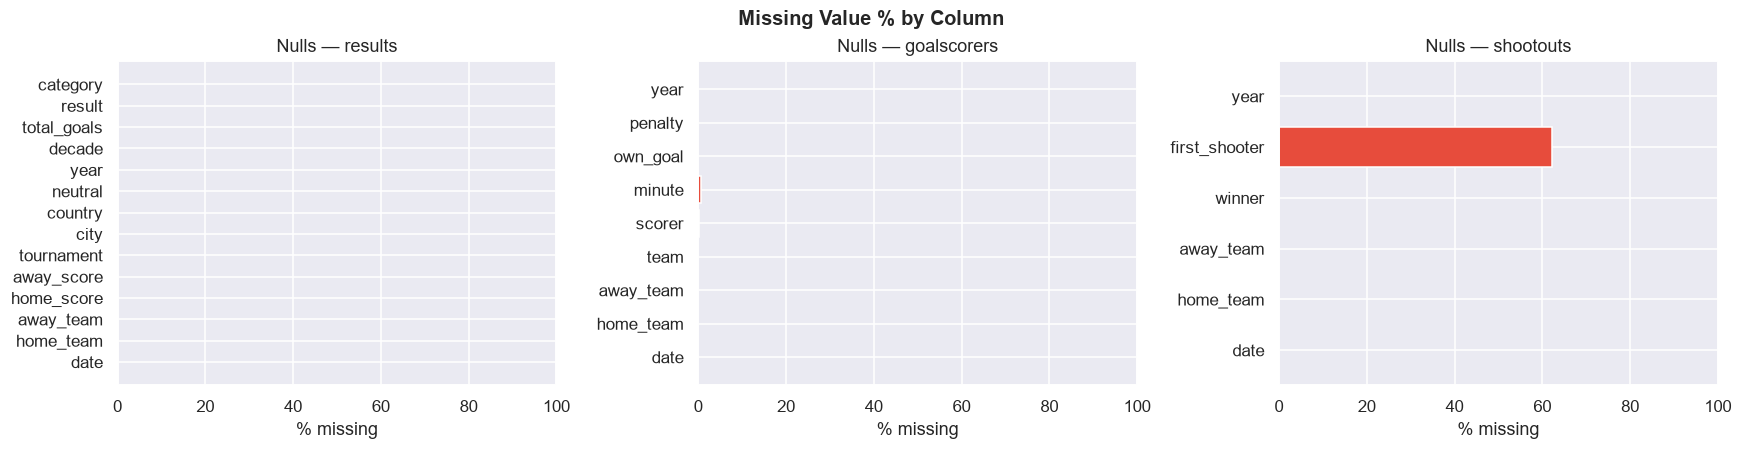

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, df) in zip(axes, [('results', results), ('goalscorers', goals), ('shootouts', shootouts)]):
    null_pct = df.isnull().mean() * 100
    bars = ax.barh(null_pct.index, null_pct.values, color=['#e74c3c' if v > 0 else '#2ecc71' for v in null_pct.values])
    ax.set_xlabel('% missing')
    ax.set_title(f'Nulls — {name}')
    ax.set_xlim(0, 100)
plt.tight_layout()
plt.suptitle('Missing Value % by Column', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## Section 2 — Match Results Overview

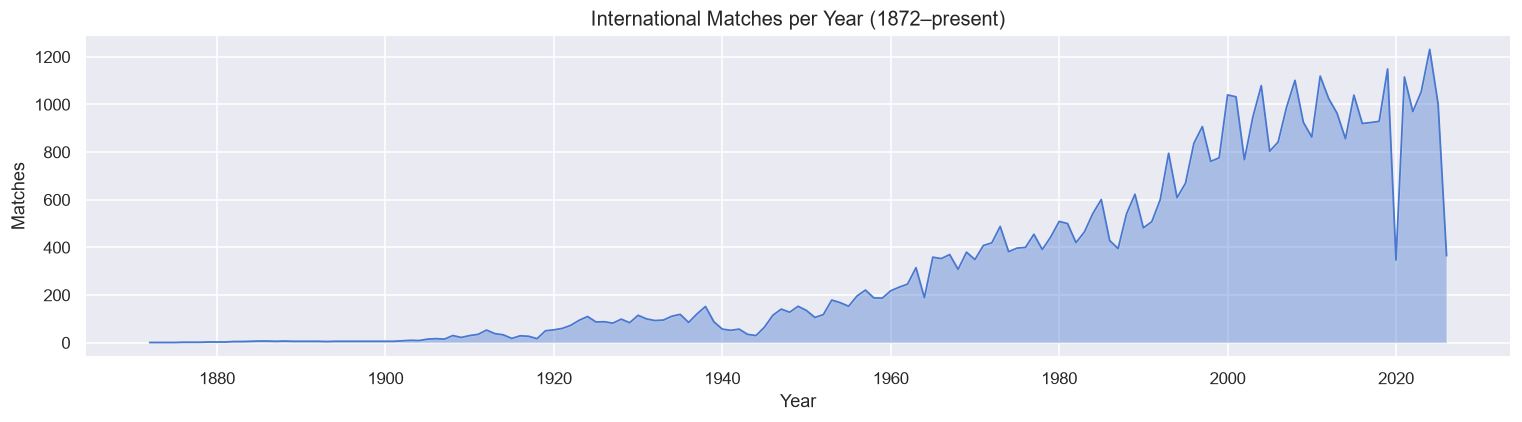

In [7]:
# Matches per year
matches_per_year = results.groupby('year').size()
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(matches_per_year.index, matches_per_year.values, alpha=0.4)
ax.plot(matches_per_year.index, matches_per_year.values, linewidth=1.2)
ax.set_title('International Matches per Year (1872–present)', fontsize=13)
ax.set_xlabel('Year');  ax.set_ylabel('Matches')
plt.tight_layout();  plt.show()

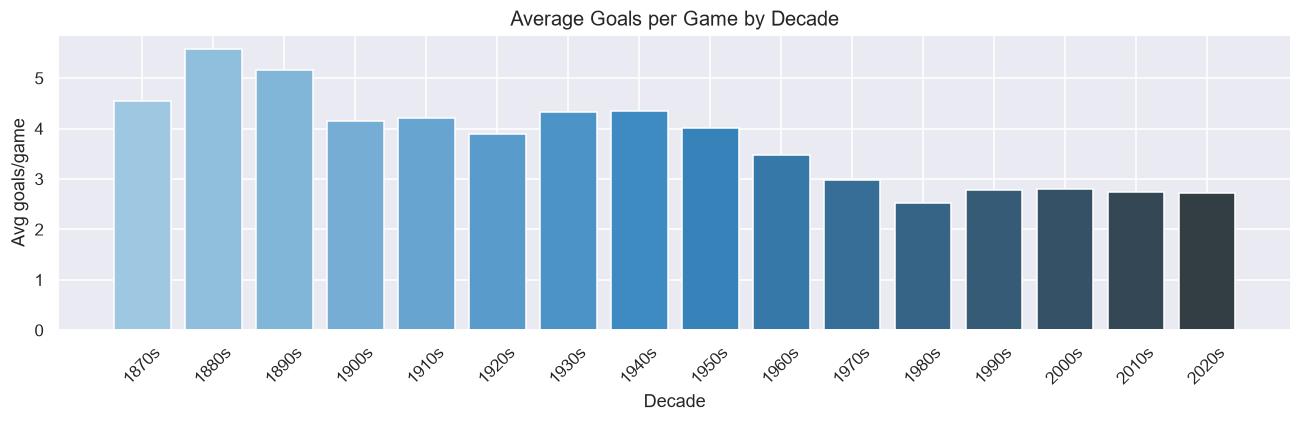

In [8]:
# Goals per game by decade
gpg = results.groupby('decade')['total_goals'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(gpg.index, gpg.values, width=8, color=sns.color_palette('Blues_d', len(gpg)))
ax.set_title('Average Goals per Game by Decade', fontsize=13)
ax.set_xlabel('Decade');  ax.set_ylabel('Avg goals/game')
ax.set_xticks(gpg.index);  ax.set_xticklabels([f"{d}s" for d in gpg.index], rotation=45)
plt.tight_layout();  plt.show()

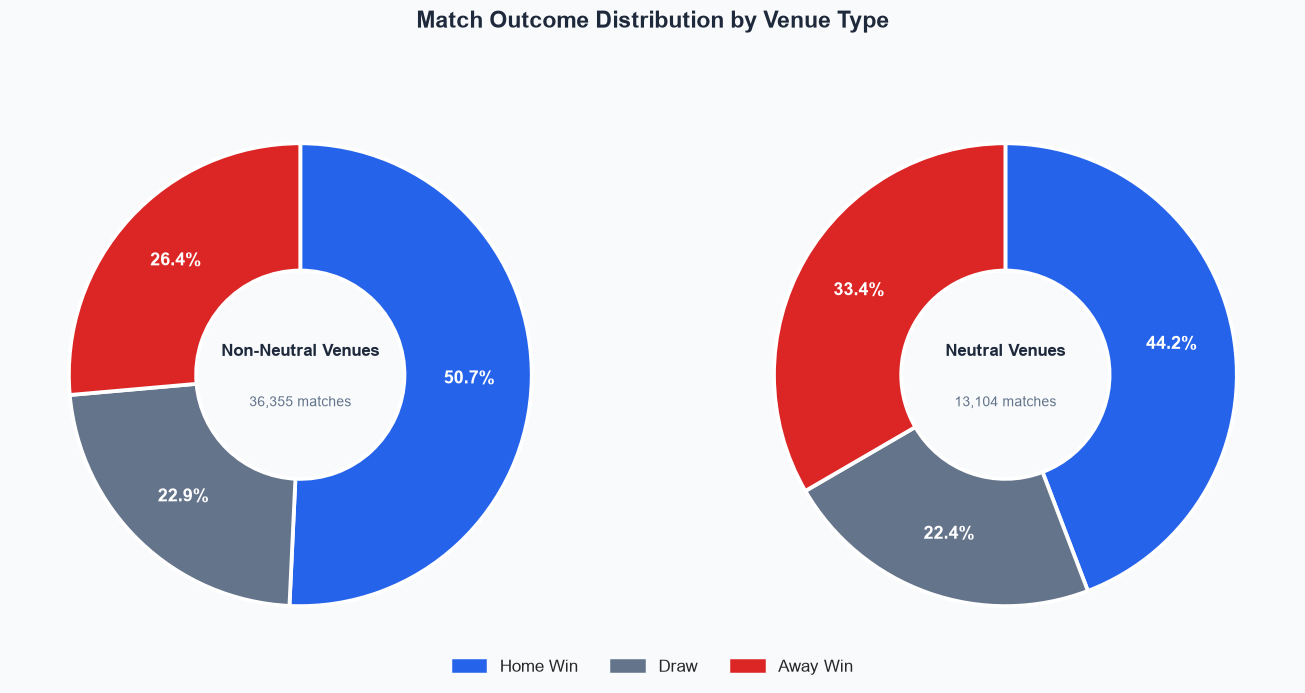

In [9]:
# Home / Away / Draw split — side-by-side donut charts
OUTCOME_COLORS = {'home_win': '#2563EB', 'draw': '#64748B', 'away_win': '#DC2626'}
OUTCOME_LABELS = {'home_win': 'Home Win', 'draw': 'Draw', 'away_win': 'Away Win'}
ORDER = ['home_win', 'draw', 'away_win']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#F8FAFC')

datasets = [
    ('Non-Neutral Venues', results[~results['neutral']]),
    ('Neutral Venues',     results[results['neutral']]),
]

for ax, (label, subset) in zip(axes, datasets):
    counts = subset['result'].value_counts().reindex(ORDER, fill_value=0)
    pct    = counts / counts.sum() * 100
    colors = [OUTCOME_COLORS[k] for k in ORDER]

    if counts.sum() == 0:
        ax.text(0.5, 0.5, 'No matches', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, fontweight='bold',
                color='#64748B')
        ax.set_aspect('equal')
        ax.set_facecolor('#F8FAFC')
        ax.axis('off')
        continue

    wedges, _ = ax.pie(
        counts.values,
        colors=colors,
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
        counterclock=False,
    )

    # percentage labels positioned inside each wedge
    for wedge, p in zip(wedges, pct.values):
        angle = (wedge.theta2 + wedge.theta1) / 2
        r = 0.73
        x = r * np.cos(np.radians(angle))
        y = r * np.sin(np.radians(angle))
        ax.text(x, y, f'{p:.1f}%', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white')

    # center annotation
    ax.text(0,  0.10, label,             ha='center', va='center',
            fontsize=11, fontweight='bold', color='#1E293B')
    ax.text(0, -0.12, f'{len(subset):,} matches', ha='center', va='center',
            fontsize=9, color='#64748B')
    ax.set_aspect('equal')
    ax.set_facecolor('#F8FAFC')

legend_handles = [mpatches.Patch(color=OUTCOME_COLORS[k], label=OUTCOME_LABELS[k]) for k in ORDER]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Match Outcome Distribution by Venue Type', fontsize=15,
             fontweight='bold', color='#1E293B', y=1.02)
plt.tight_layout()
plt.show()

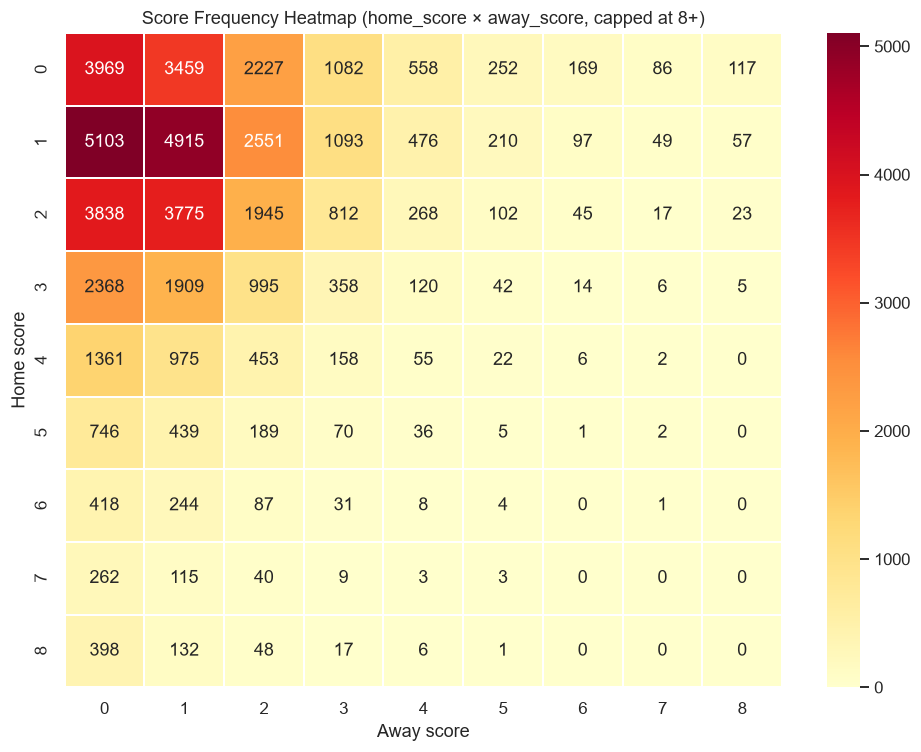

In [10]:
# Score distribution heatmap (cap at 8)
cap = 8
r = results.copy()
r['hs'] = r['home_score'].clip(0, cap)
r['as'] = r['away_score'].clip(0, cap)
heat = r.groupby(['hs', 'as']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Score Frequency Heatmap (home_score × away_score, capped at 8+)', fontsize=12)
ax.set_xlabel('Away score');  ax.set_ylabel('Home score')
plt.tight_layout();  plt.show()

## Section 3 — Tournament Breakdown

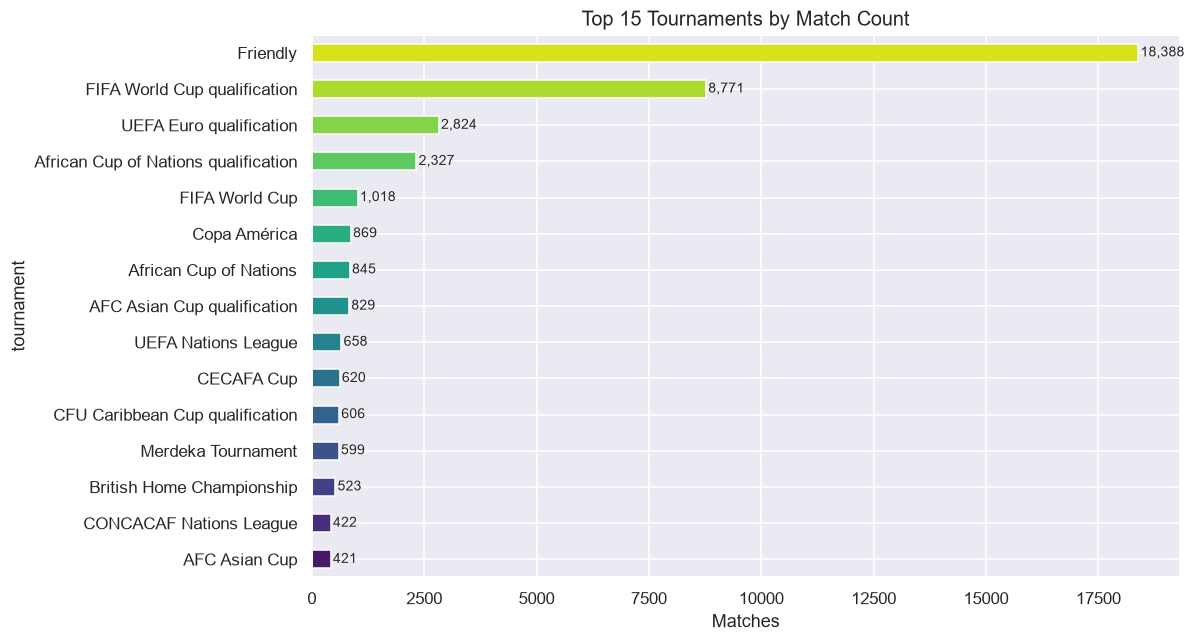

In [11]:
# Top 15 tournaments by match count
top15 = results['tournament'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(11, 6))
top15[::-1].plot.barh(ax=ax, color=sns.color_palette('viridis', 15))
ax.set_title('Top 15 Tournaments by Match Count', fontsize=13)
ax.set_xlabel('Matches')
for i, v in enumerate(top15[::-1].values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout();  plt.show()

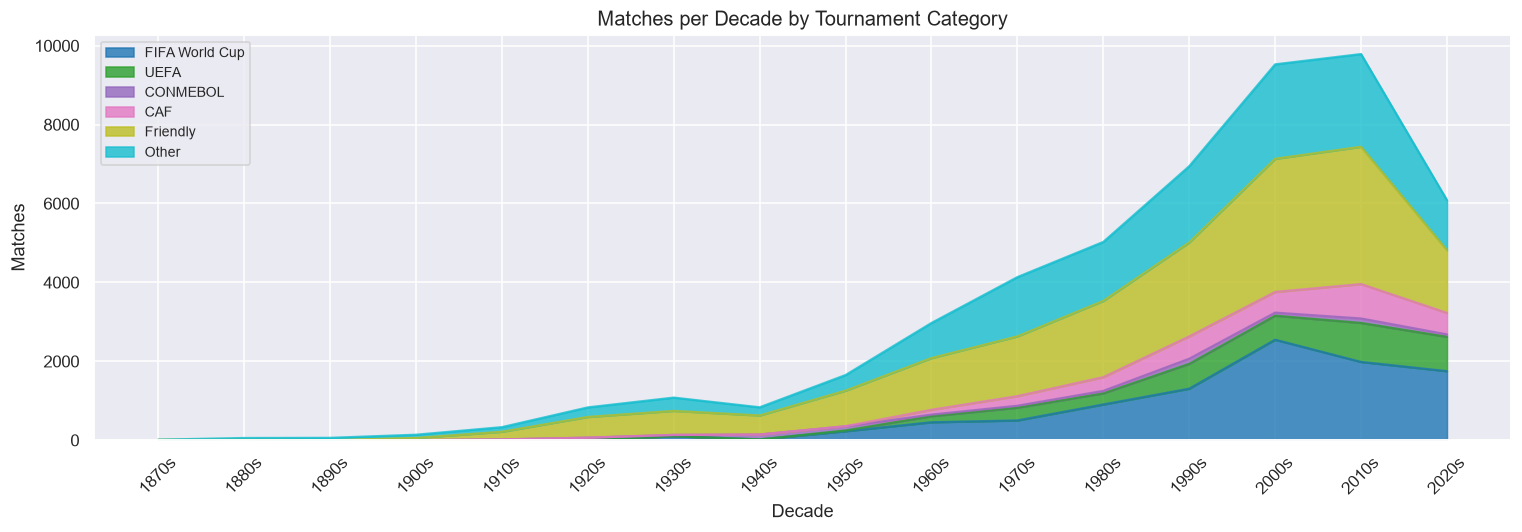

In [12]:
# Stacked area — matches per decade by tournament category
# `category` column was derived during data loading (Cell 4)
cat_decade = results.groupby(['decade', 'category']).size().unstack(fill_value=0)
cat_order  = ['FIFA World Cup', 'UEFA', 'CONMEBOL', 'CAF', 'Friendly', 'Other']
cat_decade = cat_decade.reindex(columns=cat_order, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
cat_decade.plot.area(ax=ax, alpha=0.8, colormap='tab10')
ax.set_title('Matches per Decade by Tournament Category', fontsize=13)
ax.set_xlabel('Decade');  ax.set_ylabel('Matches')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(cat_decade.index);  ax.set_xticklabels([f"{d}s" for d in cat_decade.index], rotation=45)
plt.tight_layout();  plt.show()

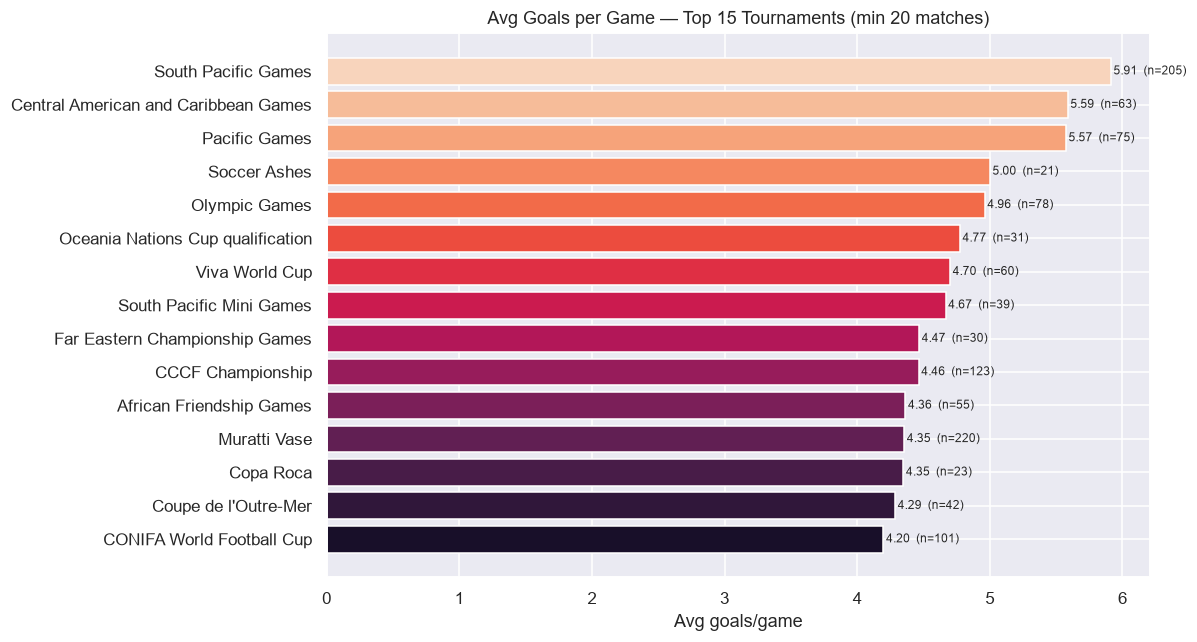

In [13]:
# Average goals per game — top 15 tournaments
gpg_tourn = (
    results.groupby('tournament')['total_goals']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .nlargest(15, 'mean')
    .sort_values('mean')
)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(gpg_tourn.index, gpg_tourn['mean'], color=sns.color_palette('rocket', len(gpg_tourn)))
ax.set_title('Avg Goals per Game — Top 15 Tournaments (min 20 matches)', fontsize=12)
ax.set_xlabel('Avg goals/game')
for i, (v, c) in enumerate(zip(gpg_tourn['mean'], gpg_tourn['count'])):
    ax.text(v + 0.02, i, f'{v:.2f}  (n={c})', va='center', fontsize=8)
plt.tight_layout();  plt.show()

## Section 4 — Top Teams & Goalscorers

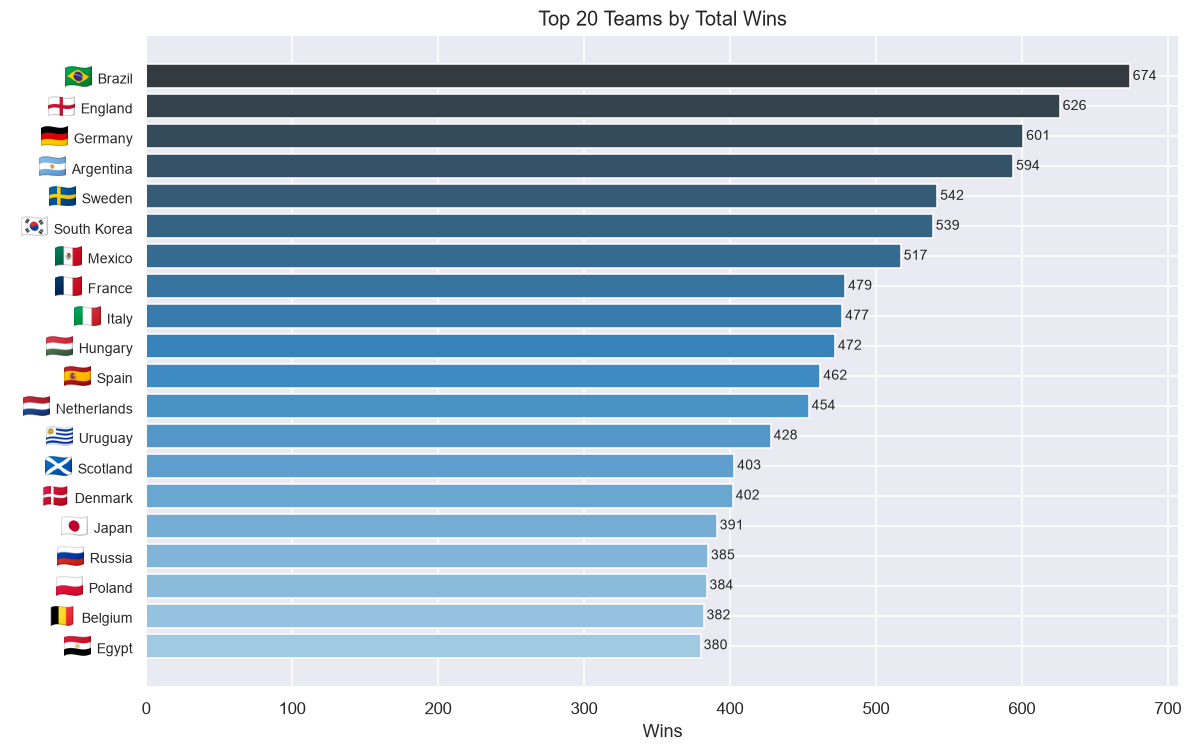

In [14]:
# Build per-team win / match counts
home = results[['home_team', 'result']].rename(columns={'home_team': 'team'})
home['win'] = (home['result'] == 'home_win').astype(int)
away = results[['away_team', 'result']].rename(columns={'away_team': 'team'})
away['win'] = (away['result'] == 'away_win').astype(int)
all_matches = pd.concat([home, away])
team_stats = all_matches.groupby('team').agg(matches=('win', 'count'), wins=('win', 'sum'))
team_stats['win_pct'] = team_stats['wins'] / team_stats['matches'] * 100

# Top 20 by wins
top20w = team_stats.nlargest(20, 'wins').sort_values('wins')
teams_w = list(top20w.index)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(teams_w, top20w['wins'].values, color=sns.color_palette('Blues_d', 20))
ax.set_title('Top 20 Teams by Total Wins', fontsize=13)
ax.set_xlabel('Wins')
for i, v in enumerate(top20w['wins']):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
add_flags_barh(ax, teams_w)
plt.tight_layout()
plt.show()


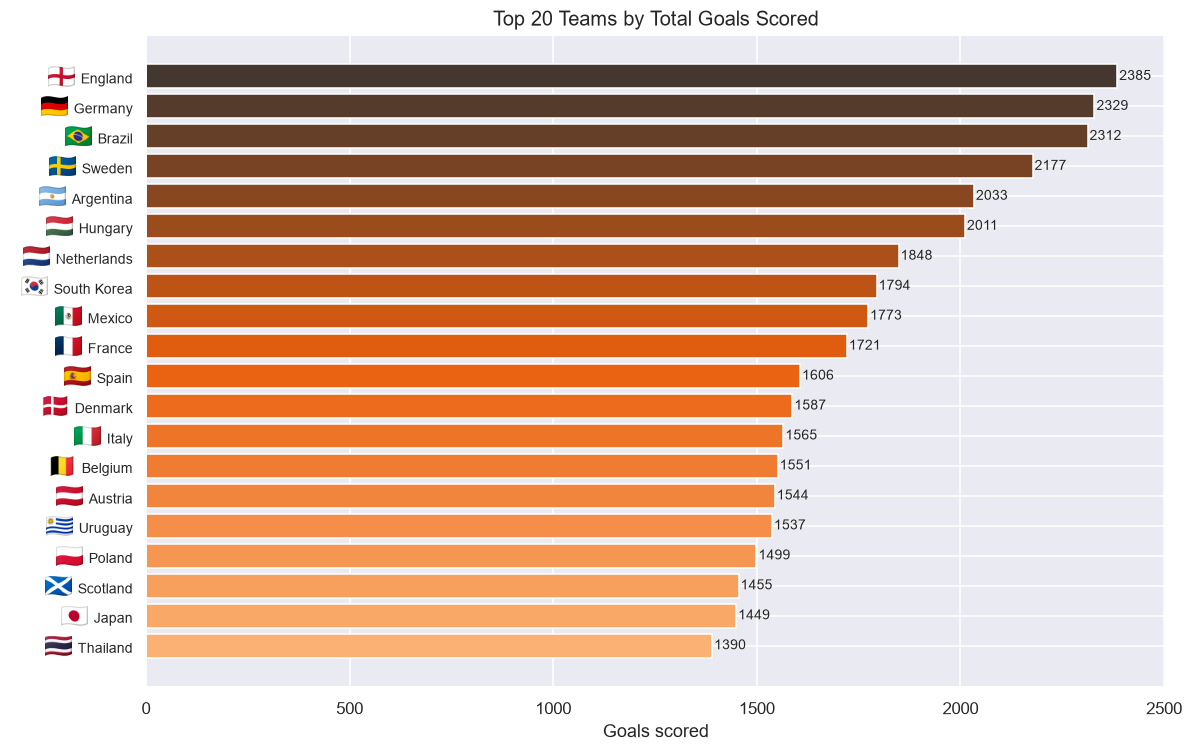

In [15]:
# Top 20 teams by goals scored
home_goals = results.groupby('home_team')['home_score'].sum().rename('goals')
away_goals = results.groupby('away_team')['away_score'].sum().rename('goals')
team_goals = (home_goals.add(away_goals, fill_value=0)).astype(int)
top20g = team_goals.nlargest(20).sort_values()
teams_g = list(top20g.index)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(teams_g, top20g.values, color=sns.color_palette('Oranges_d', 20))
ax.set_title('Top 20 Teams by Total Goals Scored', fontsize=13)
ax.set_xlabel('Goals scored')
for i, v in enumerate(top20g.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
add_flags_barh(ax, teams_g)
plt.tight_layout()
plt.show()


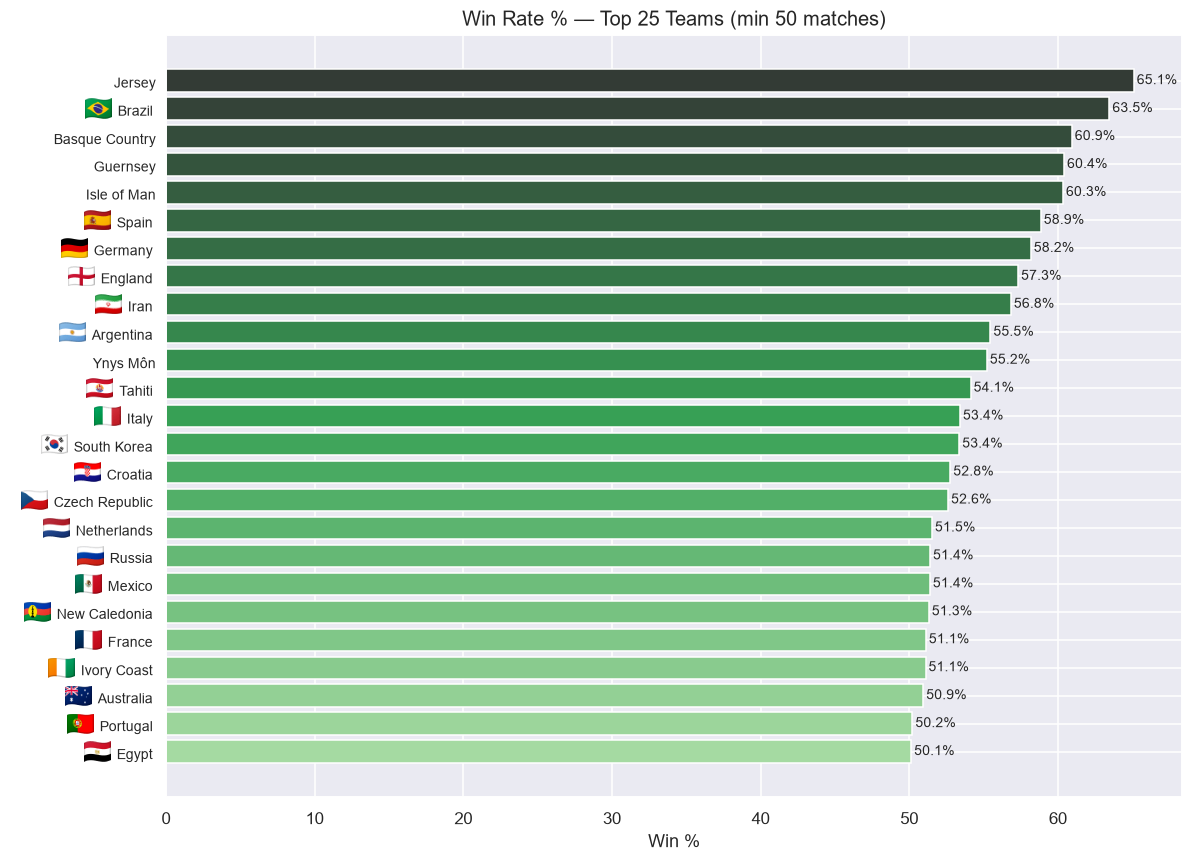

In [16]:
# Win rate for teams with >= 50 matches (top 25 by win %)
qualified = team_stats[team_stats['matches'] >= 50].nlargest(25, 'win_pct').sort_values('win_pct')
teams_q = list(qualified.index)
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(teams_q, qualified['win_pct'].values, color=sns.color_palette('Greens_d', len(qualified)))
ax.set_title('Win Rate % — Top 25 Teams (min 50 matches)', fontsize=13)
ax.set_xlabel('Win %')
for i, v in enumerate(qualified['win_pct']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
add_flags_barh(ax, teams_q)
plt.tight_layout()
plt.show()


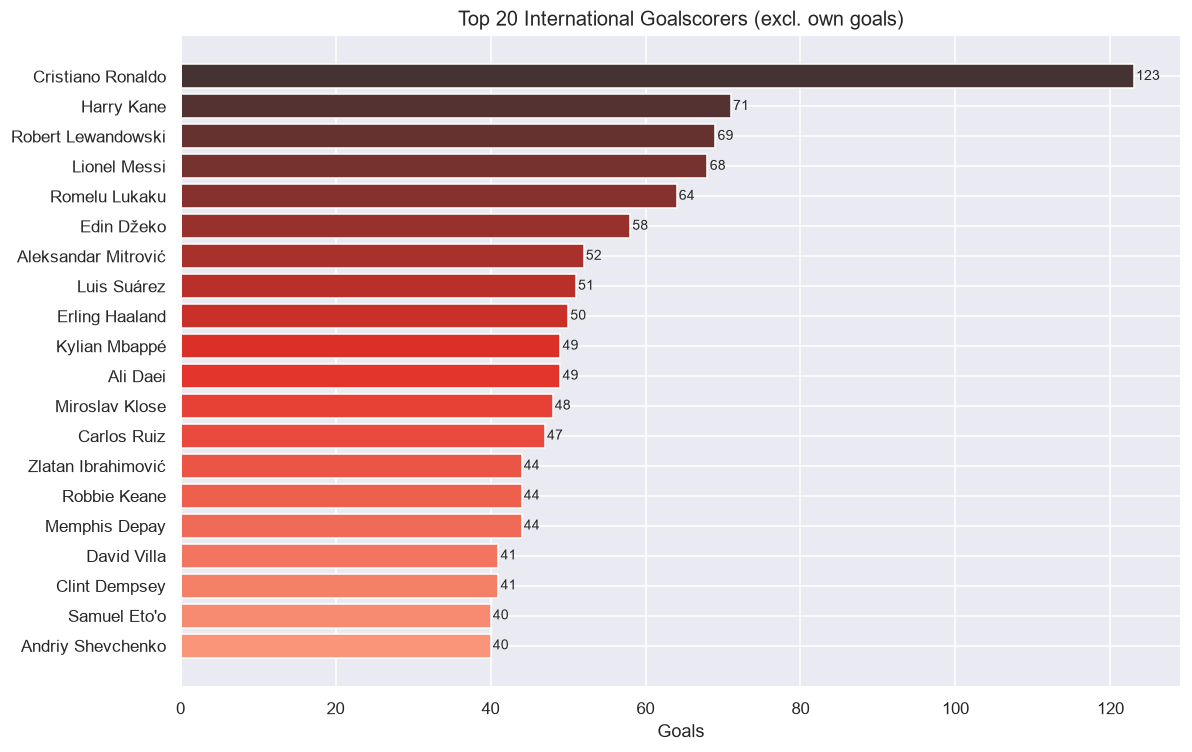

In [17]:
# Top 20 individual goalscorers (exclude own goals)
scorers = (
    goals.loc[~goals['own_goal'].fillna(False).astype(bool), 'scorer']
    .dropna()
    .value_counts()
    .head(20)
    .sort_values()
)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(scorers.index, scorers.values, color=sns.color_palette('Reds_d', 20))
ax.set_title('Top 20 International Goalscorers (excl. own goals)', fontsize=13)
ax.set_xlabel('Goals')
for i, v in enumerate(scorers.values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout();  plt.show()

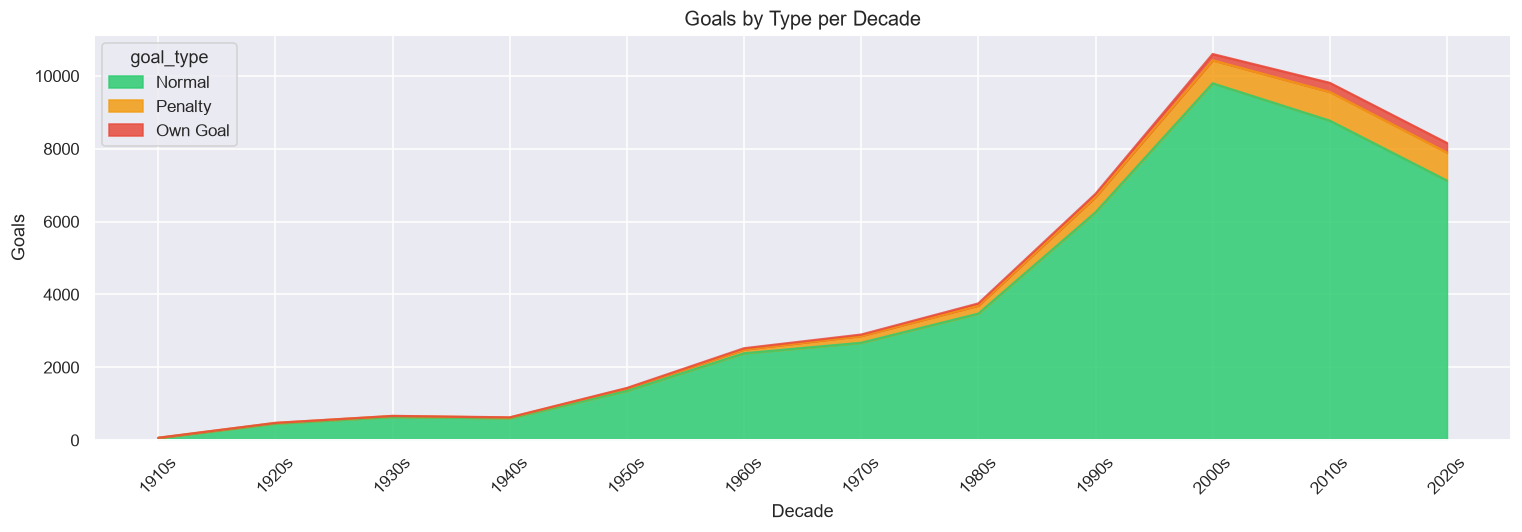

In [18]:
# Goal type breakdown over decades — Normal / Penalty / Own Goal
goals['own_goal'] = goals['own_goal'].fillna(False).astype(bool)
goals['penalty']  = goals['penalty'].fillna(False).astype(bool)

# assign in priority order: penalty and own_goal are mutually exclusive in practice
goals['goal_type'] = 'Normal'
goals.loc[goals['penalty'],  'goal_type'] = 'Penalty'
goals.loc[goals['own_goal'], 'goal_type'] = 'Own Goal'

goals['decade'] = (goals['year'] // 10) * 10
type_decade = goals.groupby(['decade', 'goal_type']).size().unstack(fill_value=0)
type_order  = ['Normal', 'Penalty', 'Own Goal']
type_decade = type_decade.reindex(columns=type_order, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
type_decade.plot.area(ax=ax, alpha=0.85, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Goals by Type per Decade', fontsize=13)
ax.set_xlabel('Decade');  ax.set_ylabel('Goals')
ax.set_xticks(type_decade.index);  ax.set_xticklabels([f"{d}s" for d in type_decade.index], rotation=45)
plt.tight_layout();  plt.show()

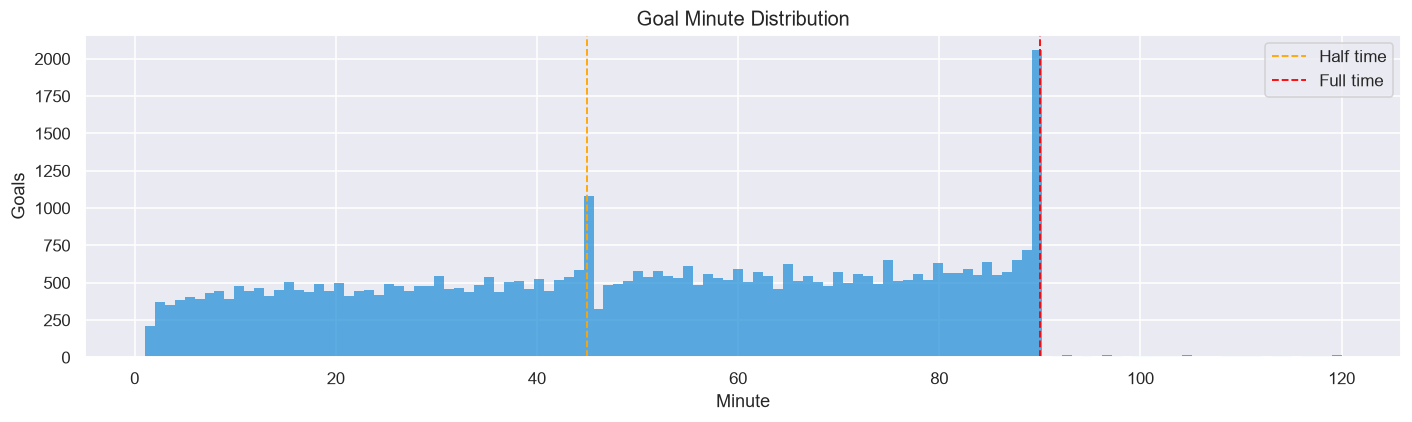

In [19]:
# Goal minute distribution
fig, ax = plt.subplots(figsize=(13, 4))
mins = goals['minute'].dropna()
mins = mins[mins <= 120]
ax.hist(mins, bins=120, color='#3498db', edgecolor='none', alpha=0.8)
ax.axvline(45,  color='orange', linestyle='--', linewidth=1.2, label='Half time')
ax.axvline(90,  color='red',    linestyle='--', linewidth=1.2, label='Full time')
ax.set_title('Goal Minute Distribution', fontsize=13)
ax.set_xlabel('Minute');  ax.set_ylabel('Goals')
ax.legend()
plt.tight_layout();  plt.show()

## Section 5 — Shootout & Penalty Stats

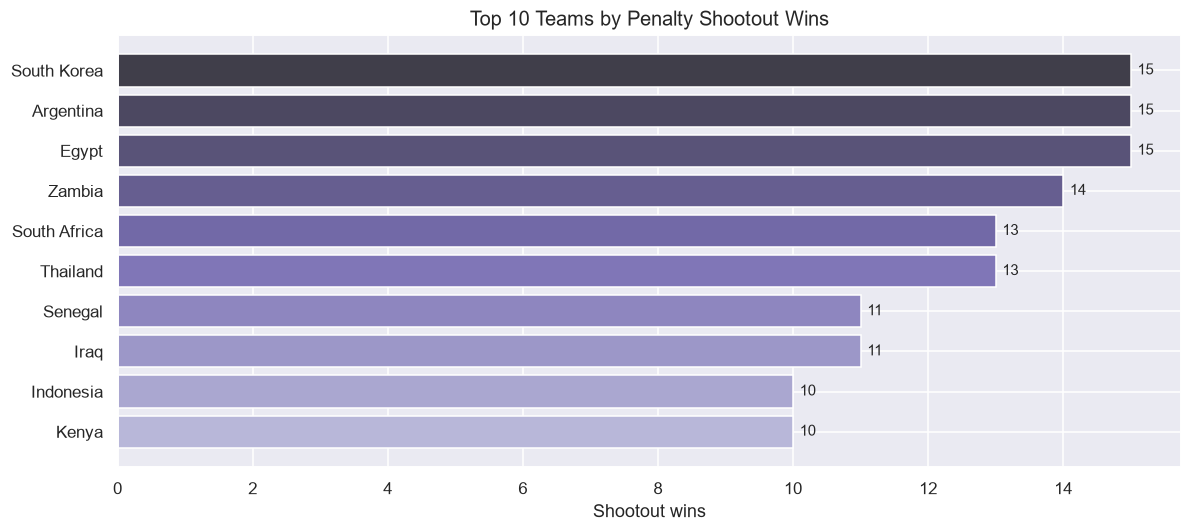

In [20]:
# Top 10 teams by shootout wins
so_wins = shootouts['winner'].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(so_wins.index, so_wins.values, color=sns.color_palette('Purples_d', 10))
ax.set_title('Top 10 Teams by Penalty Shootout Wins', fontsize=13)
ax.set_xlabel('Shootout wins')
for i, v in enumerate(so_wins.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)
plt.tight_layout();  plt.show()

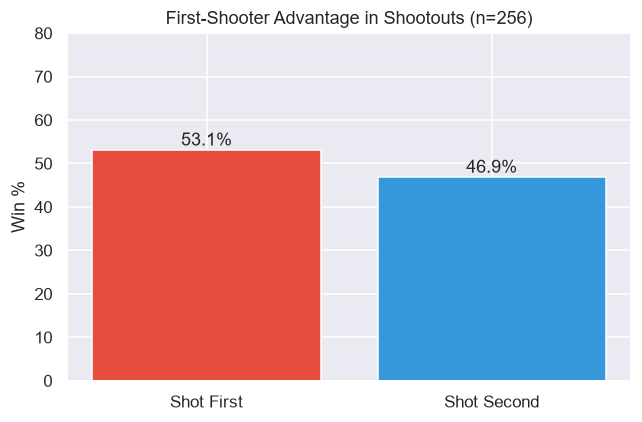

In [21]:
# First-shooter advantage
known = shootouts[shootouts['first_shooter'].notna() & (shootouts['first_shooter'] != '')].copy()
known['first_won'] = known['first_shooter'] == known['winner']
first_pct = known['first_won'].mean() * 100
second_pct = 100 - first_pct

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Shot First', 'Shot Second'], [first_pct, second_pct], color=['#e74c3c', '#3498db'])
ax.set_title(f'First-Shooter Advantage in Shootouts (n={len(known)})', fontsize=12)
ax.set_ylabel('Win %')
ax.set_ylim(0, 80)
for i, v in enumerate([first_pct, second_pct]):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12)
plt.tight_layout();  plt.show()

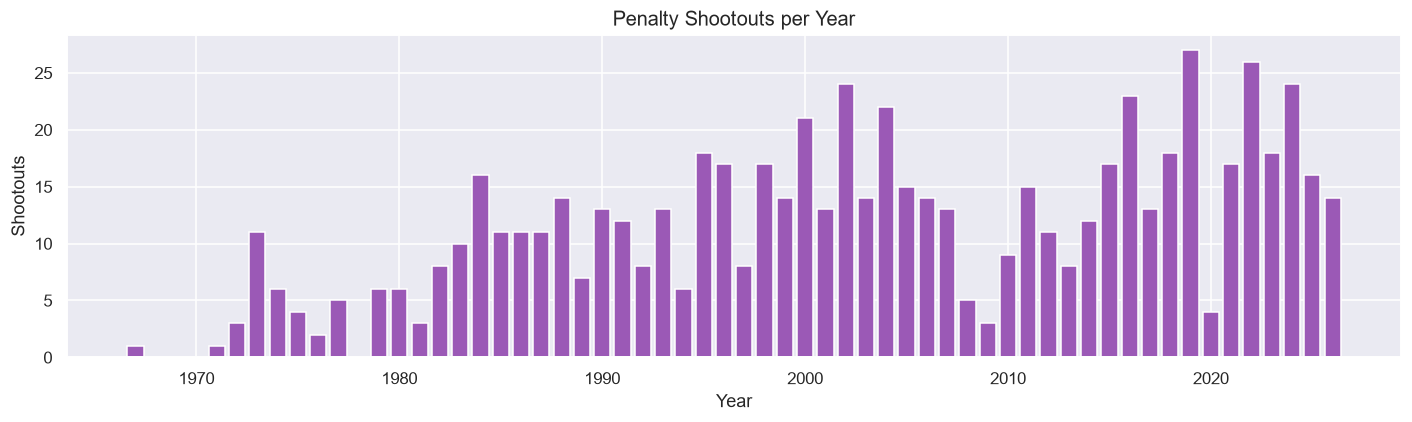

In [22]:
# Shootouts per year
so_per_year = shootouts.groupby('year').size()
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(so_per_year.index, so_per_year.values, color='#9b59b6', width=0.8)
ax.set_title('Penalty Shootouts per Year', fontsize=13)
ax.set_xlabel('Year');  ax.set_ylabel('Shootouts')
plt.tight_layout();  plt.show()

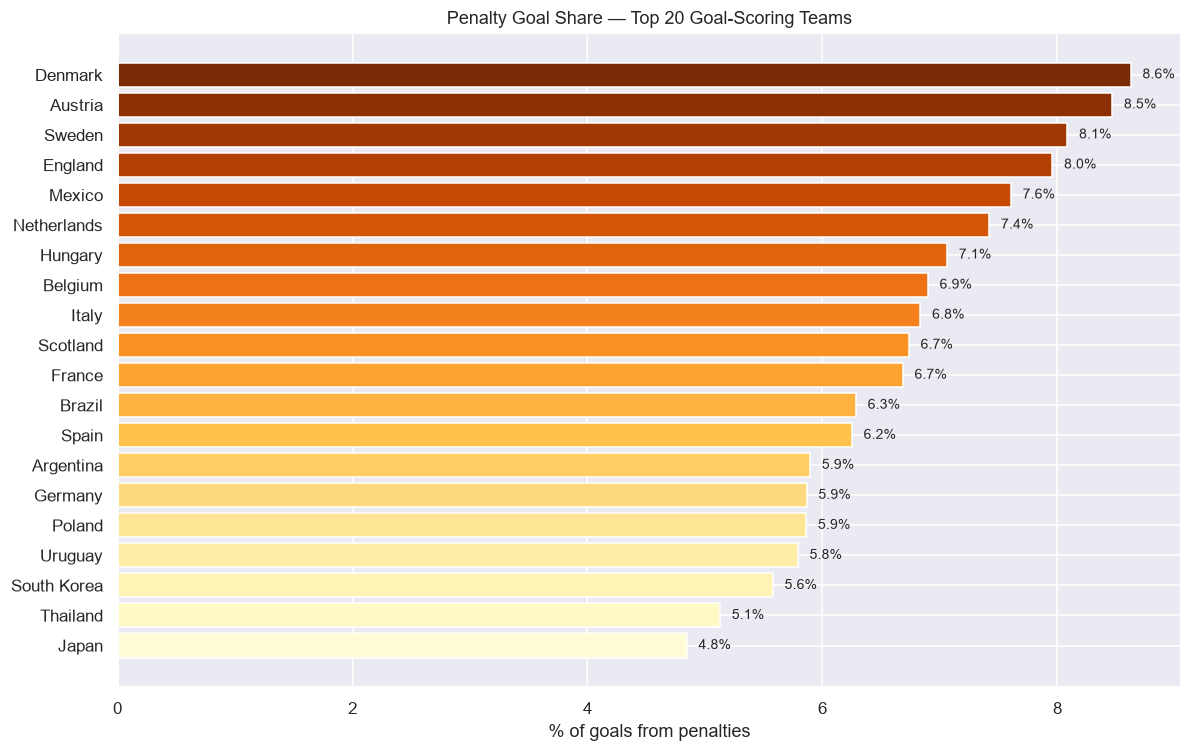

In [23]:
# Penalty goal share for top 20 scoring teams
top20_teams = team_goals.nlargest(20).index.tolist()
pen_share = (
    goals[goals['team'].isin(top20_teams)]
    .groupby('team')['penalty']
    .agg(total='count', penalties='sum')
)
pen_share['pen_pct'] = pen_share['penalties'] / pen_share['total'] * 100
pen_share = pen_share.loc[top20_teams].sort_values('pen_pct')

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(pen_share.index, pen_share['pen_pct'], color=sns.color_palette('YlOrBr', len(pen_share)))
ax.set_title('Penalty Goal Share — Top 20 Goal-Scoring Teams', fontsize=12)
ax.set_xlabel('% of goals from penalties')
for i, v in enumerate(pen_share['pen_pct']):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout();  plt.show()

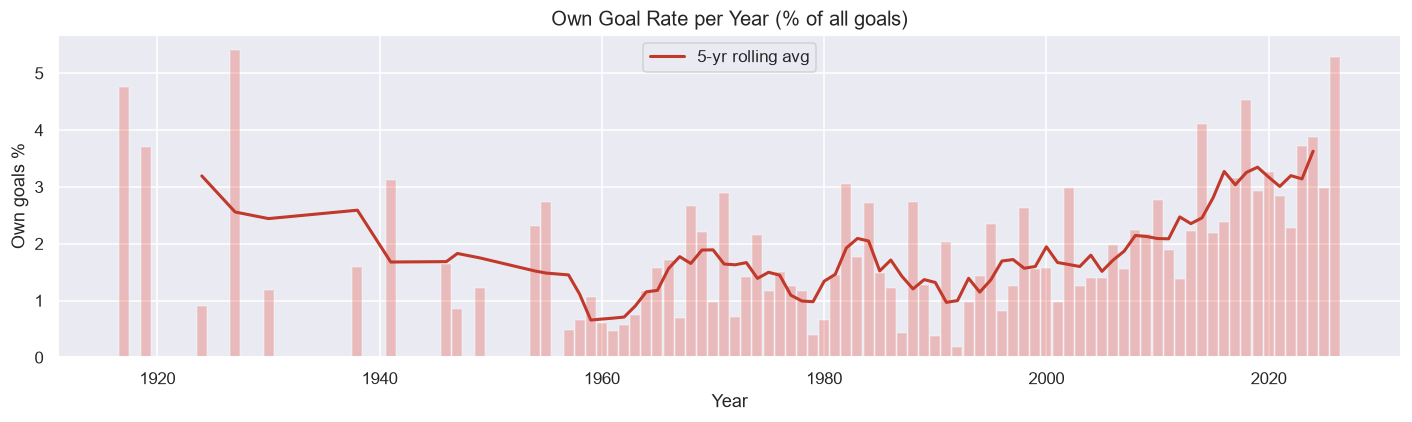

In [24]:
# Own goal rate per year (own goals / total goals)
og_per_year    = goals[goals['own_goal']].groupby('year').size()
total_per_year = goals.groupby('year').size()
og_rate = (og_per_year / total_per_year * 100).dropna()
og_rate_smooth = og_rate.rolling(5, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(og_rate.index, og_rate.values, color='#e74c3c', alpha=0.3, width=0.9)
ax.plot(og_rate_smooth.index, og_rate_smooth.values, color='#c0392b', linewidth=2, label='5-yr rolling avg')
ax.set_title('Own Goal Rate per Year (% of all goals)', fontsize=13)
ax.set_xlabel('Year');  ax.set_ylabel('Own goals %')
ax.legend()
plt.tight_layout();  plt.show()

## Section 6 — ELO Ratings

In [25]:
# ELO computation — weighted K by tournament, home advantage at non-neutral venues
K_MAP = {
    'FIFA World Cup': 60,
    'UEFA':           40,
    'CONMEBOL':       40,
    'CAF':            40,
    'Other':          35,
    'Friendly':       20,
}

elo = {}          # team -> current elo
elo_history = {}  # team -> list of (date, elo)

def get_elo(team):
    return elo.setdefault(team, 1500)

results_sorted = results.sort_values('date')

# iterate via list-of-dicts — ~5-10x faster than iterrows()
rows = results_sorted[['date', 'home_team', 'away_team', 'result', 'neutral', 'category']].to_dict('records')

for row in rows:
    h, a = row['home_team'], row['away_team']
    eh, ea = get_elo(h), get_elo(a)

    # home advantage: +100 effective ELO for non-neutral venues
    home_bonus = 0 if row['neutral'] else 100
    exp_h = 1 / (1 + 10 ** ((ea - (eh + home_bonus)) / 400))
    exp_a = 1 - exp_h

    if row['result'] == 'home_win':   act_h, act_a = 1, 0
    elif row['result'] == 'away_win': act_h, act_a = 0, 1
    else:                             act_h, act_a = 0.5, 0.5

    K = K_MAP.get(row['category'], 30)
    elo[h] = eh + K * (act_h - exp_h)
    elo[a] = ea + K * (act_a - exp_a)

    d = row['date']
    elo_history.setdefault(h, []).append((d, elo[h]))
    elo_history.setdefault(a, []).append((d, elo[a]))

elo_series = pd.Series(elo).sort_values(ascending=False)
print('ELO computed for', len(elo_series), 'teams')
print(elo_series.head(10).to_string())

ELO computed for 336 teams
Argentina    2090.024165
Spain        2071.735887
France       2049.738222
England      1986.269898
Brazil       1980.057672
Colombia     1973.297469
Germany      1958.451207
Morocco      1954.669332
Portugal     1953.934075
Japan        1938.182940


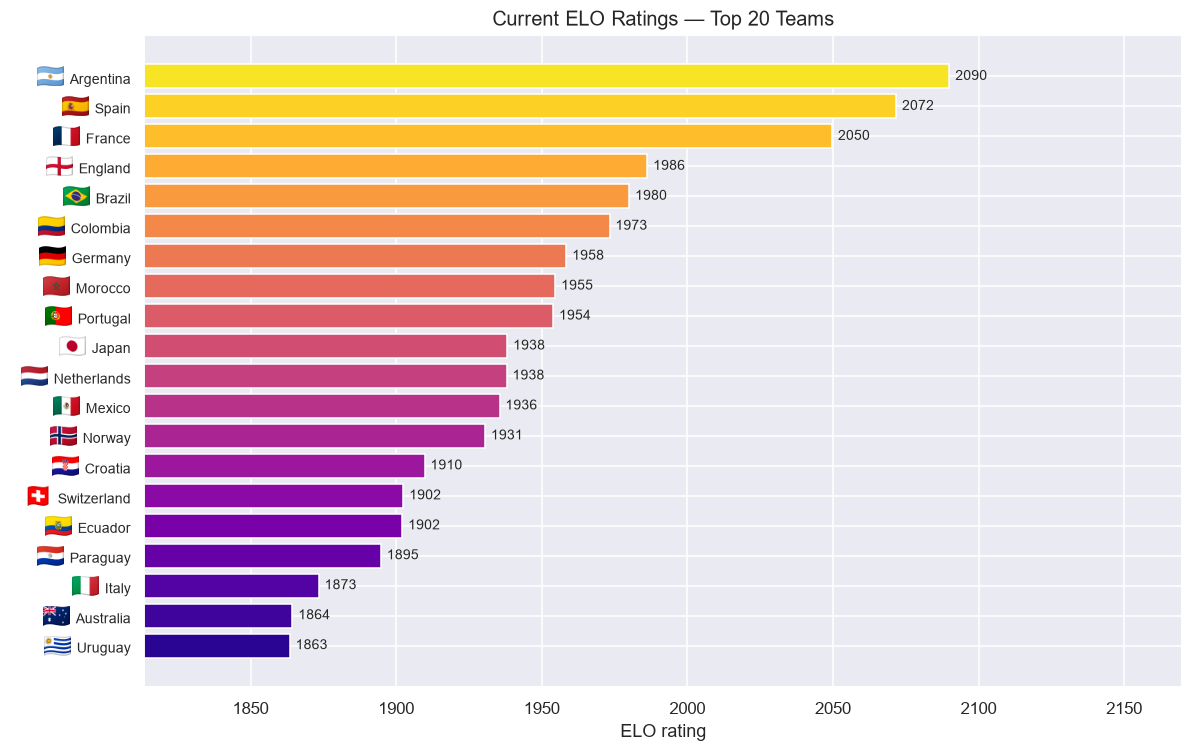

In [26]:
# Current ELO — top 20
top20_elo = elo_series.head(20).sort_values()
teams_elo = list(top20_elo.index)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(teams_elo, top20_elo.values, color=sns.color_palette('plasma', 20))
ax.set_title('Current ELO Ratings — Top 20 Teams', fontsize=13)
ax.set_xlabel('ELO rating')
ax.set_xlim(top20_elo.min() - 50, top20_elo.max() + 80)
for i, v in enumerate(top20_elo.values):
    ax.text(v + 2, i, f'{v:.0f}', va='center', fontsize=9)
add_flags_barh(ax, teams_elo)
plt.tight_layout()
plt.show()


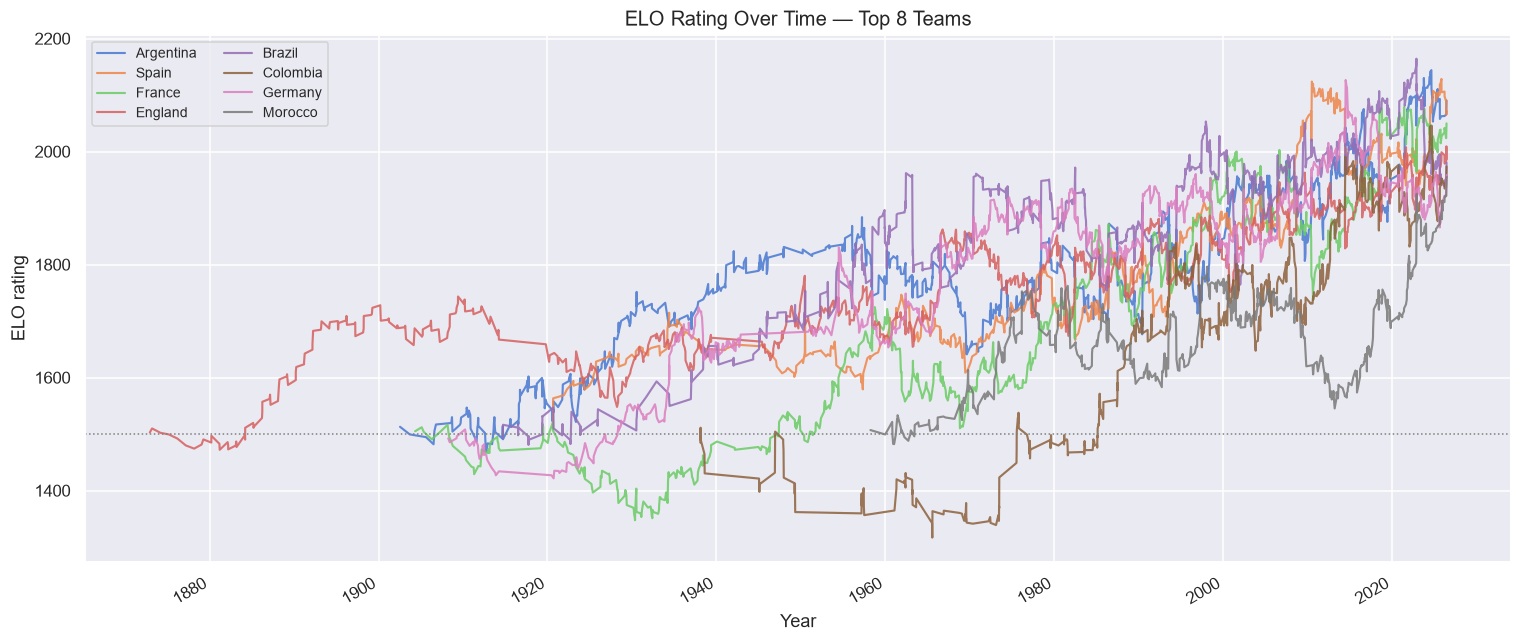

In [27]:
# ELO history for top 8 current teams
top8 = elo_series.head(8).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for team in top8:
    hist = pd.DataFrame(elo_history[team], columns=['date', 'elo']).set_index('date')
    hist['elo'].plot(ax=ax, label=team, linewidth=1.4, alpha=0.85)
ax.set_title('ELO Rating Over Time — Top 8 Teams', fontsize=13)
ax.set_xlabel('Year');  ax.set_ylabel('ELO rating')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.axhline(1500, color='gray', linestyle=':', linewidth=1, label='Starting ELO')
plt.tight_layout();  plt.show()

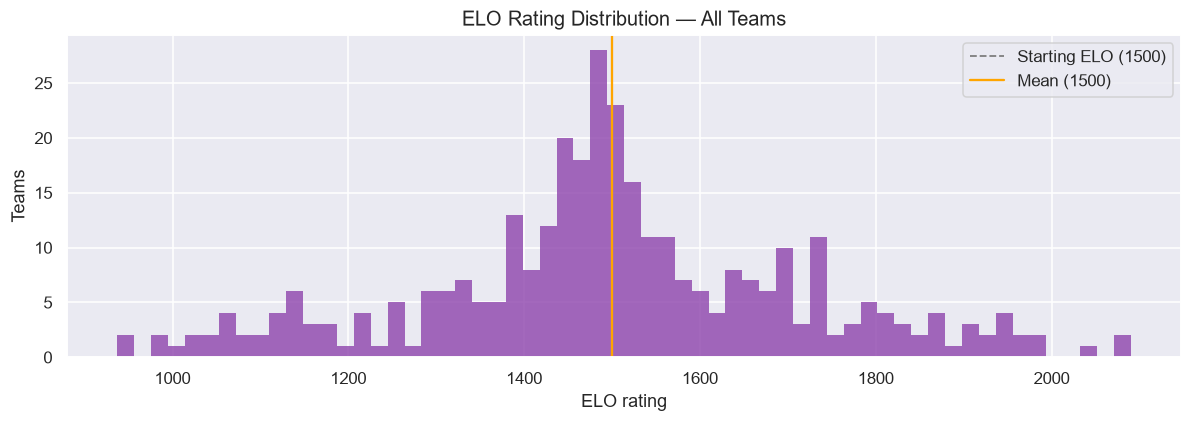

In [28]:
# ELO distribution across all teams
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(elo_series.values, bins=60, color='#8e44ad', edgecolor='none', alpha=0.8)
ax.axvline(1500, color='gray',   linestyle='--', linewidth=1.2, label='Starting ELO (1500)')
ax.axvline(elo_series.mean(), color='orange', linestyle='-', linewidth=1.5, label=f'Mean ({elo_series.mean():.0f})')
ax.set_title('ELO Rating Distribution — All Teams', fontsize=13)
ax.set_xlabel('ELO rating');  ax.set_ylabel('Teams')
ax.legend()
plt.tight_layout();  plt.show()

## Section 7 — FIFA World Cup 2026 Live Results Dashboard

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

wc = pd.read_csv('data/worldcup2026_clean.csv')
wc['match_datetime'] = pd.to_datetime(wc['match_datetime'])
wc['finished'] = wc['finished'].map({True: True, False: False, 'True': True, 'False': False})

finished = wc[wc['finished'] == True].copy()
group_matches = finished[finished['type'] == 'group'].copy()

print(f"Total finished matches: {len(finished)}")
print(f"Group stage finished:   {len(group_matches)}")
print(f"Groups with data:       {sorted(group_matches['group'].unique())}")
print(f"Total goals scored:     {group_matches['total_goals'].sum()}")
print(f"Avg goals per game:     {group_matches['total_goals'].mean():.2f}")

Total finished matches: 60
Group stage finished:   60
Groups with data:       ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
Total goals scored:     177
Avg goals per game:     2.95


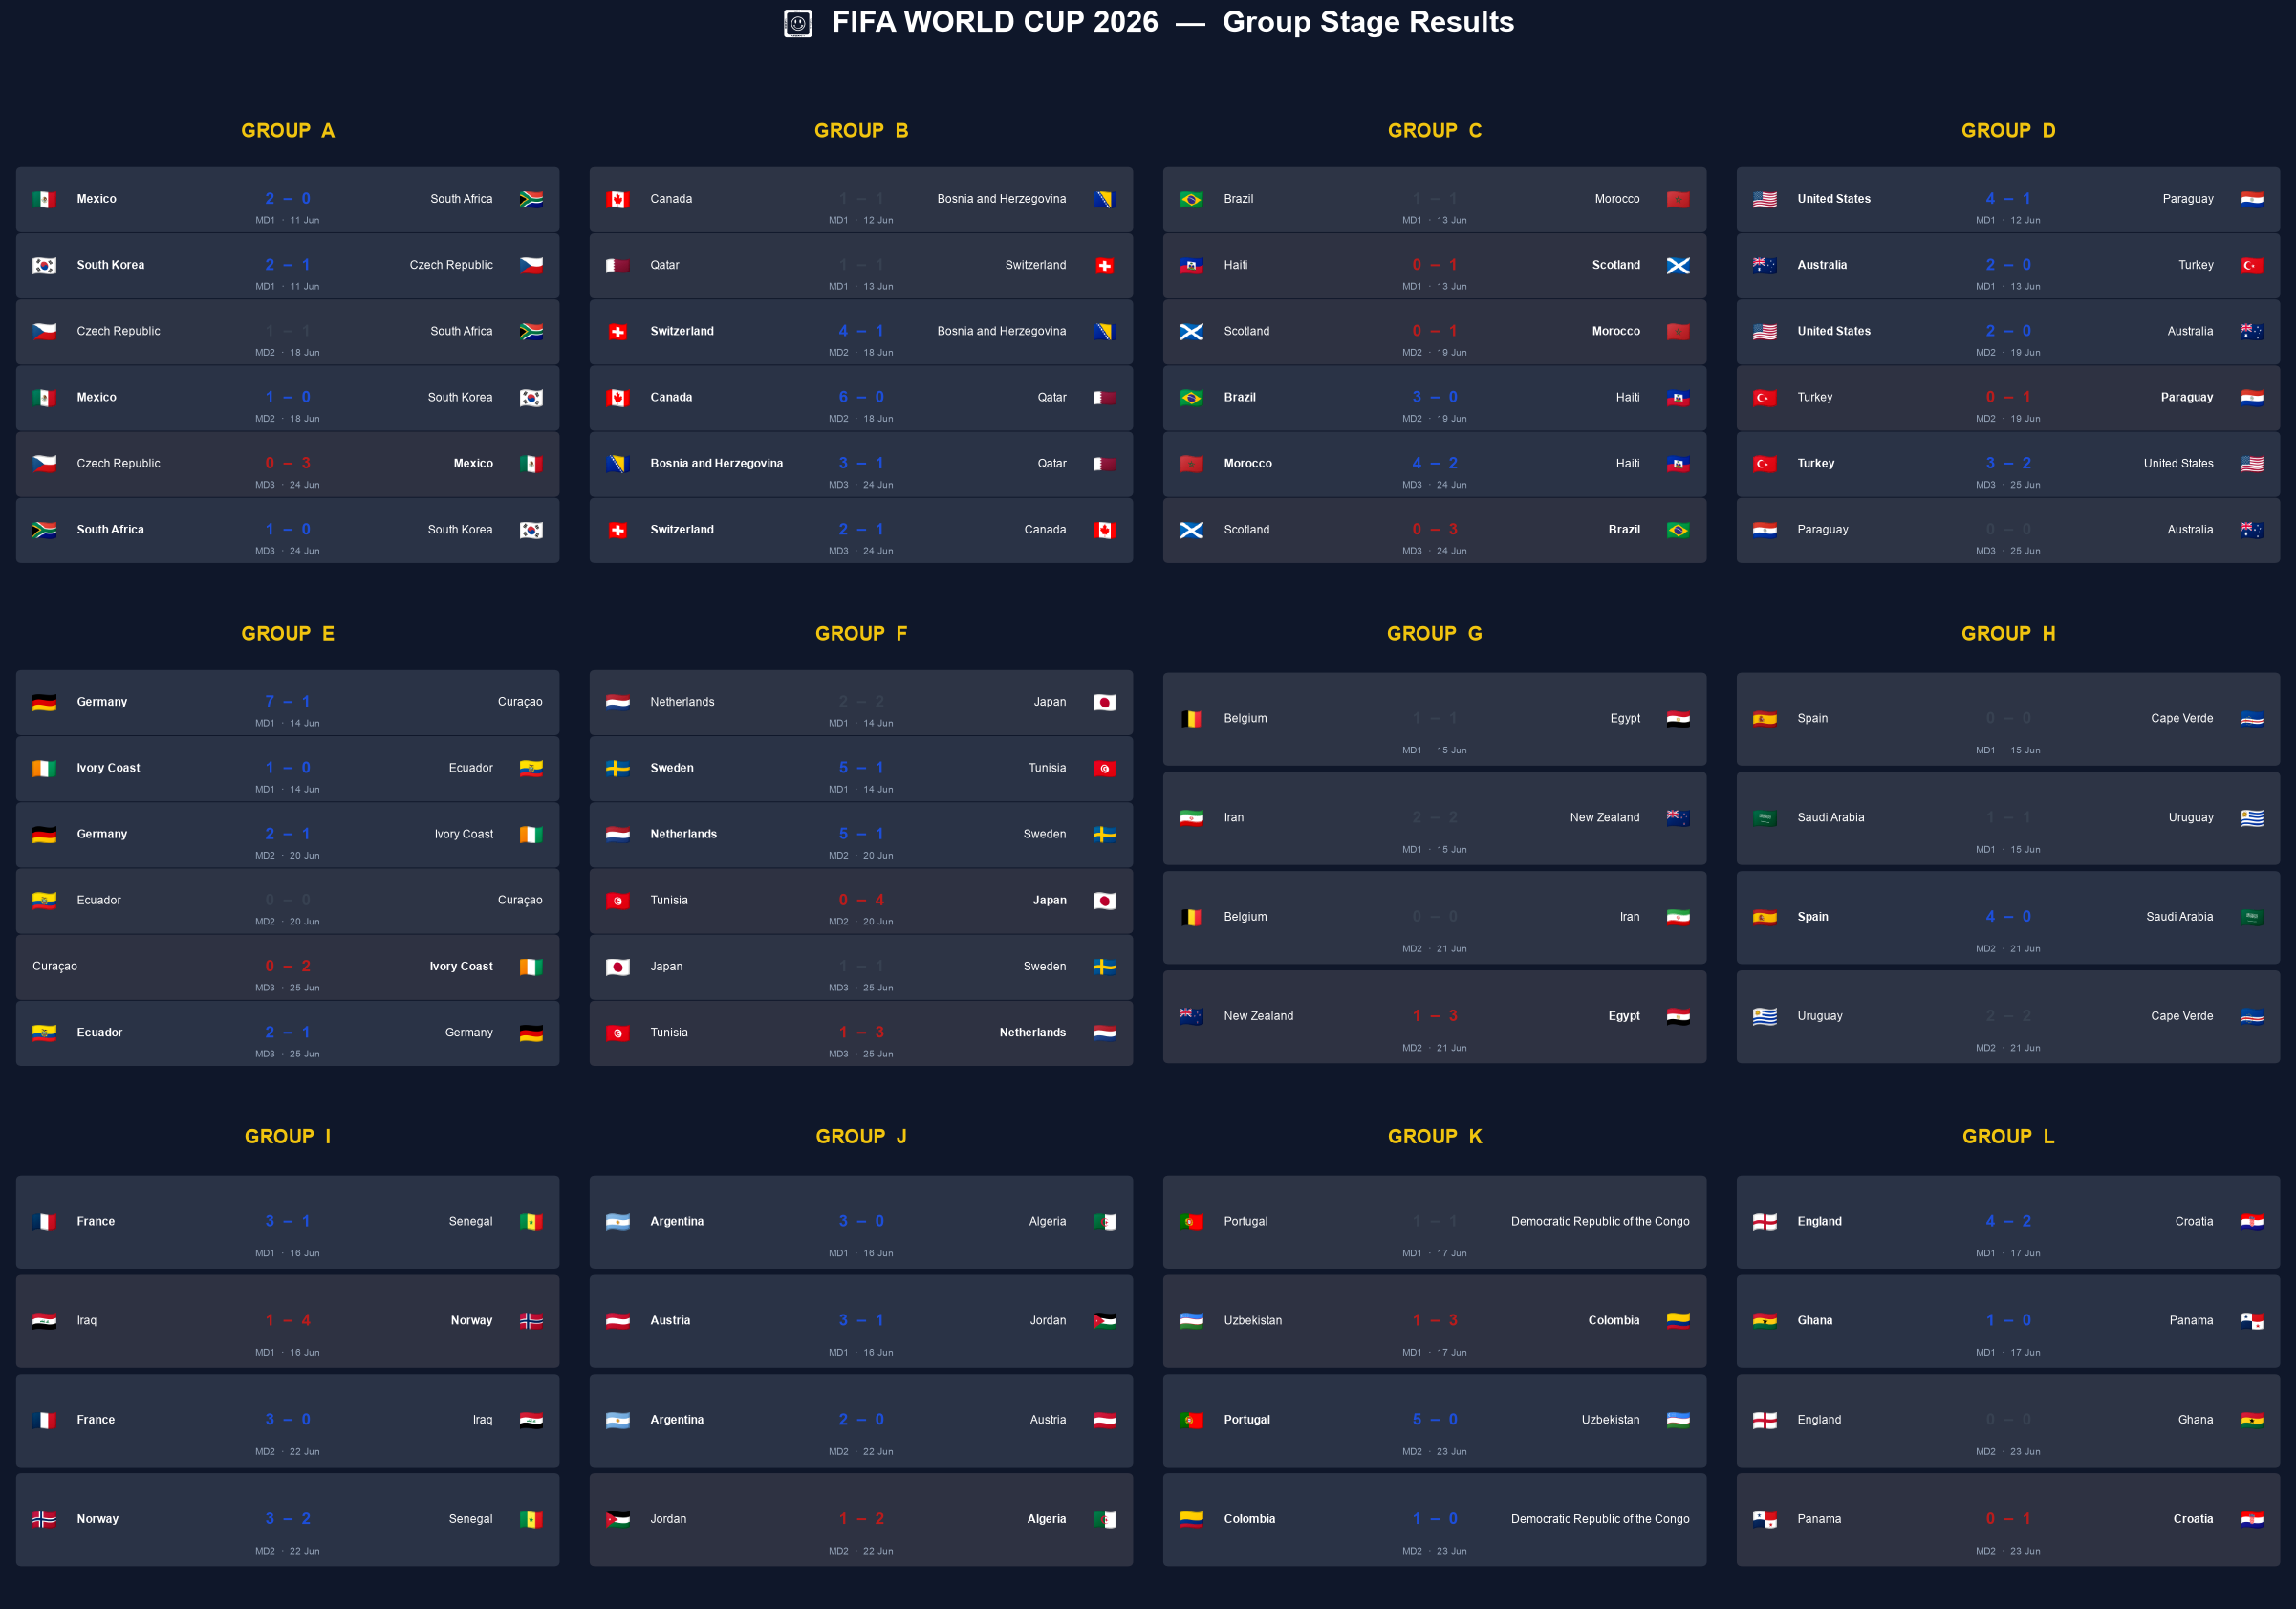

In [30]:
# ── Match Results Board — all finished group matches, arranged by group ─────────
RESULT_COLORS = {
    'home_win':  ('#1D4ED8', '#DBEAFE'),
    'away_win':  ('#B91C1C', '#FEE2E2'),
    'draw':      ('#374151', '#F3F4F6'),
}

groups = sorted(group_matches['group'].unique())
ncols = 4
nrows = -(-len(groups) // ncols)

fig = plt.figure(figsize=(22, nrows * 5.2))
fig.patch.set_facecolor('#0F172A')
fig.suptitle('⚽  FIFA WORLD CUP 2026  —  Group Stage Results',
             fontsize=20, fontweight='bold', color='white', y=0.98)

for gi, grp in enumerate(groups):
    ax = fig.add_subplot(nrows, ncols, gi + 1)
    ax.set_facecolor('#1E293B')
    ax.set_xlim(0, 1)
    gdata = group_matches[group_matches['group'] == grp].sort_values('match_datetime')

    ax.text(0.5, 0.97, f'GROUP  {grp}', ha='center', va='top',
            fontsize=13, fontweight='bold', color='#F1C40F',
            transform=ax.transAxes)

    n = len(gdata)
    row_h = 0.82 / max(n, 1)

    for ri, (_, row) in enumerate(gdata.iterrows()):
        yc = 0.88 - ri * row_h - row_h / 2
        result = row['match_result']
        dark, light = RESULT_COLORS.get(result, ('#374151', '#F3F4F6'))

        rect = FancyBboxPatch((0.02, yc - row_h * 0.42), 0.96, row_h * 0.84,
                               boxstyle='round,pad=0.01', linewidth=0,
                               facecolor=light + '22', edgecolor=dark + '88',
                               transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)

        home_bold = 'bold' if result == 'home_win' else 'normal'
        away_bold = 'bold' if result == 'away_win' else 'normal'

        # Home: flag → name
        h_flag = get_flag_img(row['home_team'])
        if h_flag is not None:
            ib = OffsetImage(h_flag, zoom=0.5)
            ib.image.axes = ax
            ab = AnnotationBbox(ib, (0.04, yc), xycoords=ax.transAxes,
                                frameon=False, box_alignment=(0, 0.5), clip_on=False)
            ax.add_artist(ab)
            ax.text(0.12, yc, row['home_team'], ha='left', va='center',
                    fontsize=8, fontweight=home_bold, color='white',
                    transform=ax.transAxes)
        else:
            ax.text(0.04, yc, row['home_team'], ha='left', va='center',
                    fontsize=8, fontweight=home_bold, color='white',
                    transform=ax.transAxes)

        # Away: name ← flag
        a_flag = get_flag_img(row['away_team'])
        if a_flag is not None:
            ax.text(0.87, yc, row['away_team'], ha='right', va='center',
                    fontsize=8, fontweight=away_bold, color='white',
                    transform=ax.transAxes)
            ib = OffsetImage(a_flag, zoom=0.5)
            ib.image.axes = ax
            ab = AnnotationBbox(ib, (0.96, yc), xycoords=ax.transAxes,
                                frameon=False, box_alignment=(1, 0.5), clip_on=False)
            ax.add_artist(ab)
        else:
            ax.text(0.96, yc, row['away_team'], ha='right', va='center',
                    fontsize=8, fontweight=away_bold, color='white',
                    transform=ax.transAxes)

        ax.text(0.5, yc, f"{int(row['home_score'])}  –  {int(row['away_score'])}",
                ha='center', va='center', fontsize=11, fontweight='bold',
                color=dark, transform=ax.transAxes)

        day_str = row['match_datetime'].strftime('%d %b')
        ax.text(0.5, yc - row_h * 0.32, f'MD{int(row["matchday"])}  ·  {day_str}',
                ha='center', va='center', fontsize=6.5, color='#94A3B8',
                transform=ax.transAxes)

    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


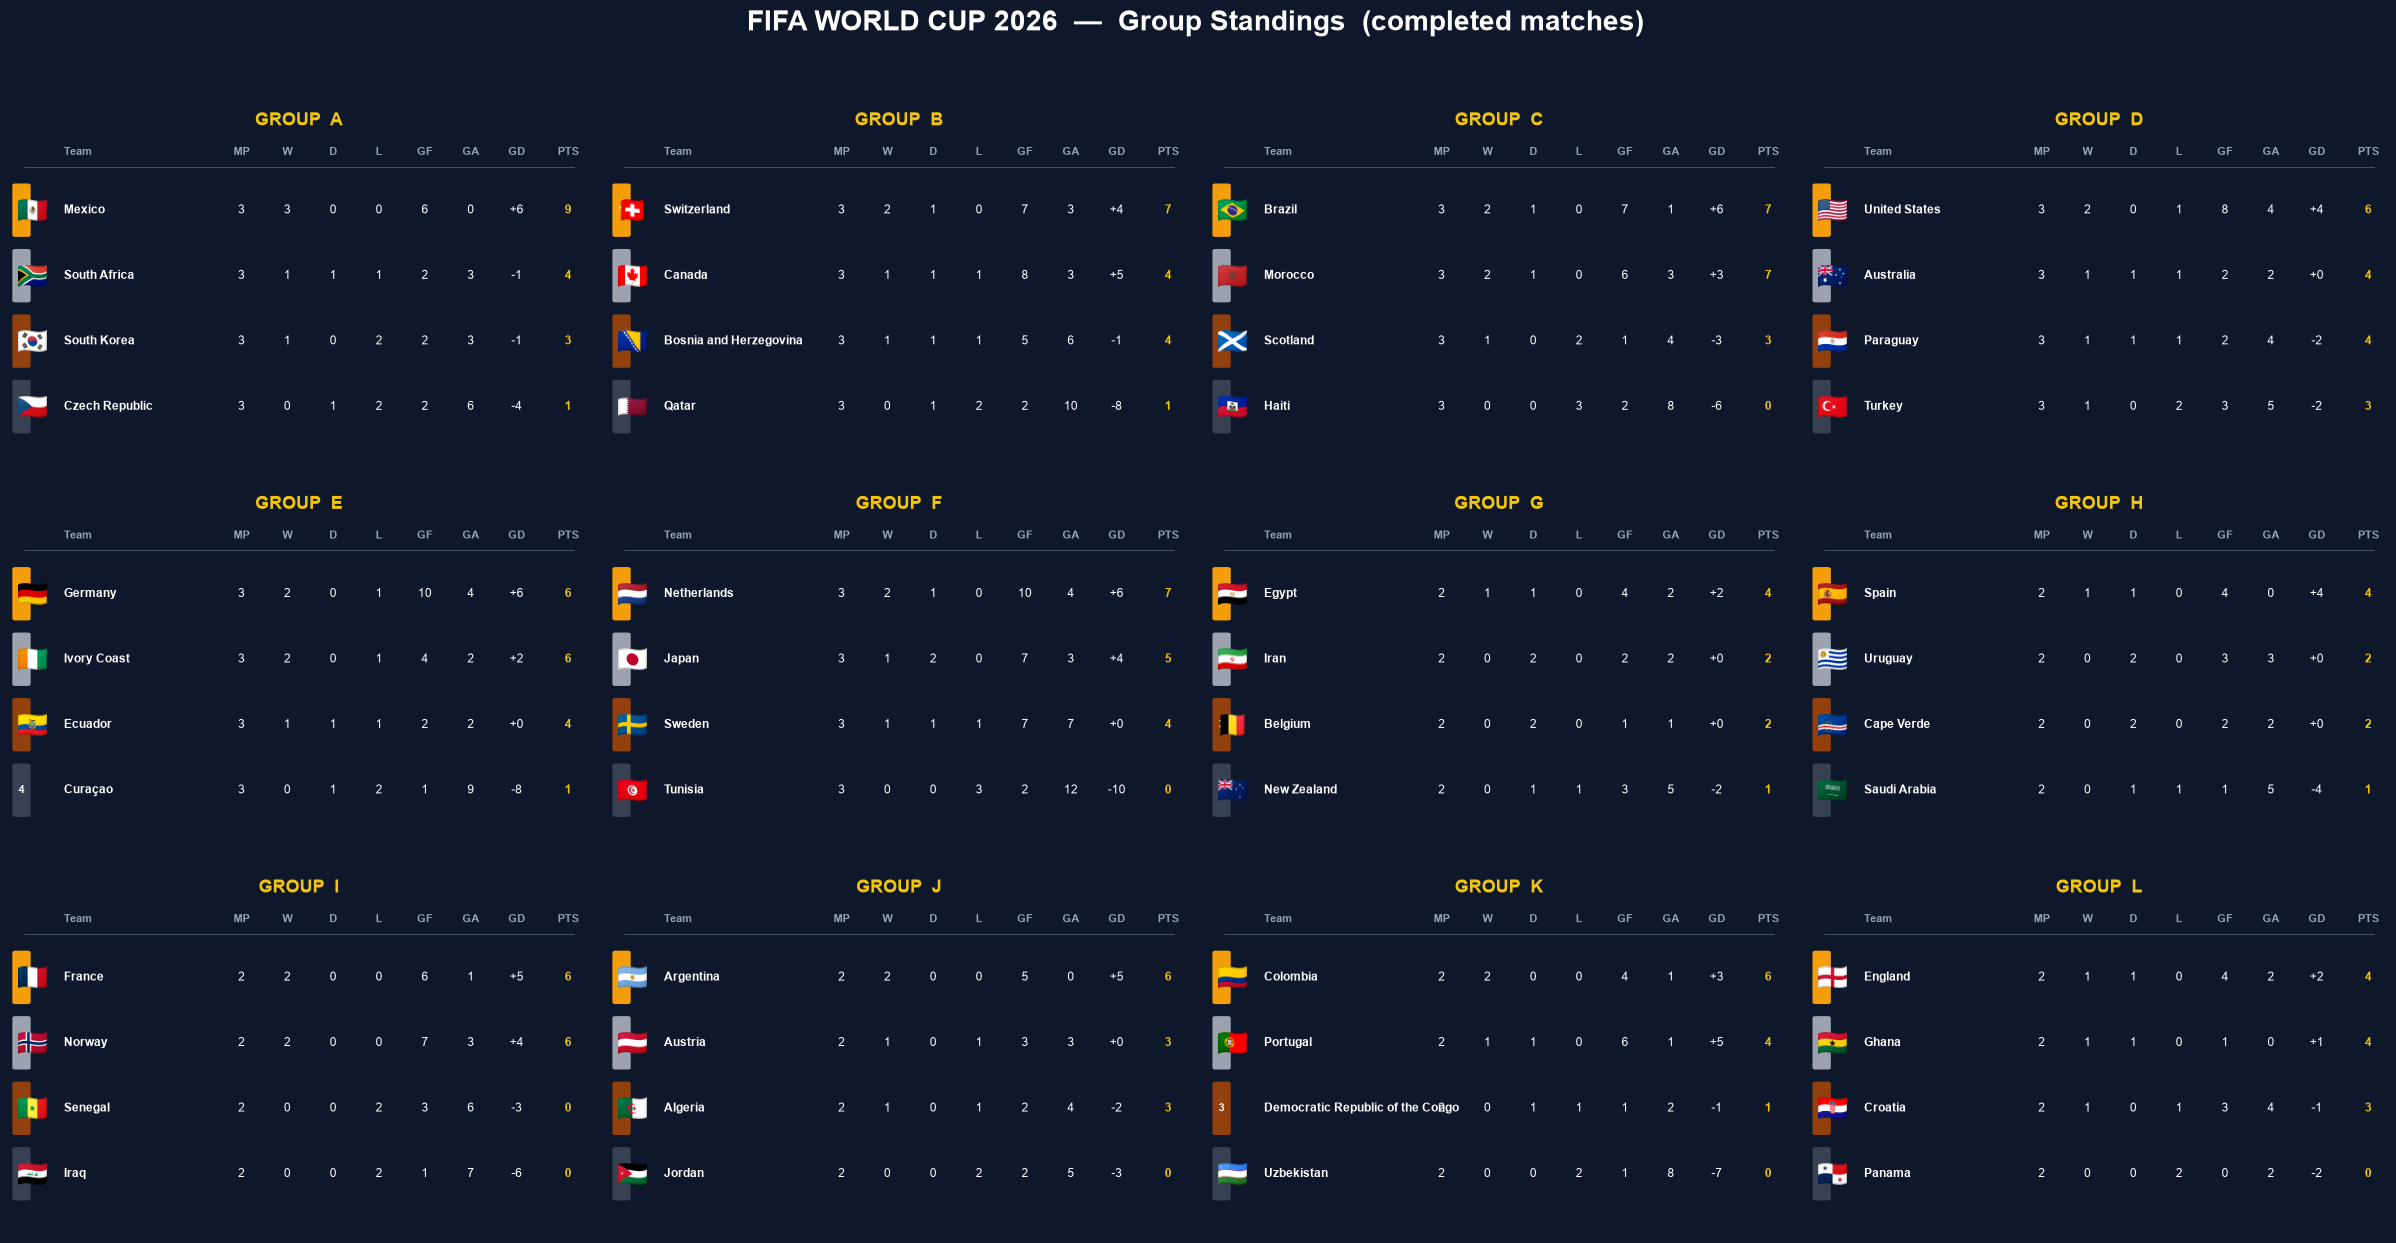

In [31]:
def build_standings(df):
    rows = []
    for _, m in df.iterrows():
        h, a = m['home_team'], m['away_team']
        hs, as_ = int(m['home_score']), int(m['away_score'])
        res = m['match_result']
        h_pts = 3 if res == 'home_win' else (1 if res == 'draw' else 0)
        a_pts = 3 if res == 'away_win' else (1 if res == 'draw' else 0)
        rows += [
            {'team': h, 'pts': h_pts, 'gf': hs, 'ga': as_, 'w': int(res=='home_win'), 'd': int(res=='draw'), 'l': int(res=='away_win')},
            {'team': a, 'pts': a_pts, 'gf': as_, 'ga': hs, 'w': int(res=='away_win'), 'd': int(res=='draw'), 'l': int(res=='home_win')},
        ]
    s = pd.DataFrame(rows).groupby('team').sum().reset_index()
    s['gd'] = s['gf'] - s['ga']
    s['mp'] = s['w'] + s['d'] + s['l']
    return s.sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)

groups = sorted(group_matches['group'].unique())
ncols = 4
nrows_g = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows_g, ncols, figsize=(22, nrows_g * 3.8))
fig.patch.set_facecolor('#0F172A')
fig.suptitle('FIFA WORLD CUP 2026  —  Group Standings  (completed matches)',
             fontsize=18, fontweight='bold', color='white', y=0.99)

axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

COL_LABELS = ['Team', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'PTS']
FLAG_X  = 0.035          # flag centre x (axes coords)
TEAM_X  = 0.09           # team name x (shifted right of flag)
COL_X   = [TEAM_X, 0.40, 0.48, 0.56, 0.64, 0.72, 0.80, 0.88, 0.97]

RANK_COLORS = ['#F59E0B', '#9CA3AF', '#92400E', '#374151']

for gi, grp in enumerate(groups):
    ax = axes_flat[gi]
    ax.set_facecolor('#1E293B')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

    ax.text(0.5, 0.97, f'GROUP  {grp}', ha='center', va='top',
            fontsize=12, fontweight='bold', color='#F1C40F', transform=ax.transAxes)

    for cx, lbl in zip(COL_X, COL_LABELS):
        ax.text(cx, 0.86, lbl, ha='left' if lbl == 'Team' else 'center',
                va='center', fontsize=7.5, fontweight='bold', color='#94A3B8',
                transform=ax.transAxes)
    ax.axhline(0.82, xmin=0.02, xmax=0.98, color='#475569', linewidth=0.6)

    standings = build_standings(group_matches[group_matches['group'] == grp])
    n_teams = len(standings)
    row_h = 0.72 / max(n_teams, 1)

    for ri, row in standings.iterrows():
        yc = 0.79 - ri * row_h - row_h / 2
        rc = RANK_COLORS[ri] if ri < len(RANK_COLORS) else '#374151'

        # rank badge
        ax.add_patch(FancyBboxPatch((0.005, yc - row_h*0.38), 0.022, row_h*0.76,
                                     boxstyle='round,pad=0.005', facecolor=rc,
                                     edgecolor='none', transform=ax.transAxes))
        ax.text(0.016, yc, str(ri + 1), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white', transform=ax.transAxes)

        # flag
        flag_img = get_flag_img(row['team'])
        if flag_img is not None:
            ib = OffsetImage(flag_img, zoom=0.6)
            ib.image.axes = ax
            ab = AnnotationBbox(ib, (FLAG_X, yc), xycoords=ax.transAxes,
                                frameon=False, box_alignment=(0.5, 0.5), clip_on=False)
            ax.add_artist(ab)

        vals = [row['team'], row['mp'], row['w'], row['d'], row['l'],
                row['gf'], row['ga'],
                ('+' if row['gd'] >= 0 else '') + str(int(row['gd'])),
                int(row['pts'])]
        for ci, (cx, v) in enumerate(zip(COL_X, vals)):
            color = '#F1C40F' if ci == len(vals)-1 else 'white'
            fw = 'bold' if ci in (0, len(vals)-1) else 'normal'
            ax.text(cx, yc, str(v), ha='left' if ci == 0 else 'center',
                    va='center', fontsize=8, fontweight=fw, color=color,
                    transform=ax.transAxes)

for gi in range(len(groups), len(axes_flat)):
    axes_flat[gi].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


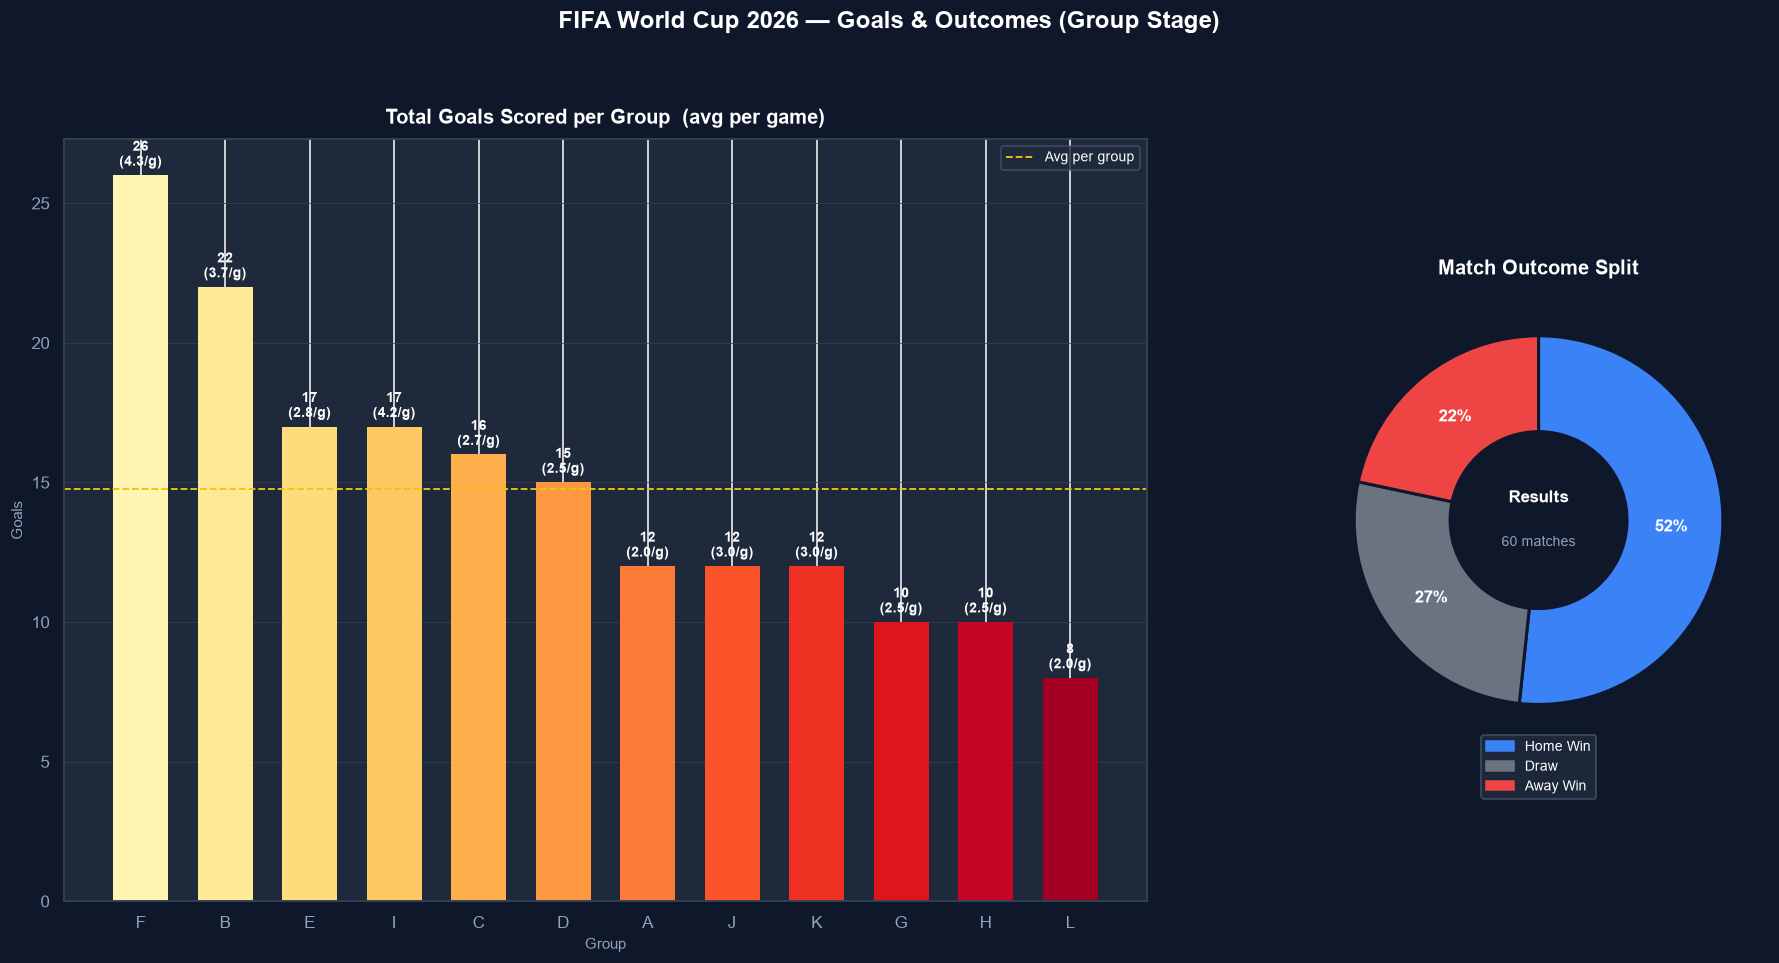

In [32]:
# ── Goals Analysis: total per group + match result distribution ─────────────────
fig = plt.figure(figsize=(20, 9))
fig.patch.set_facecolor('#0F172A')

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])

for ax in [ax1, ax2]:
    ax.set_facecolor('#1E293B')
    for sp in ax.spines.values():
        sp.set_color('#334155')

# — Goals per group bar chart —
goals_by_group = group_matches.groupby('group').agg(
    total_goals=('total_goals', 'sum'),
    matches=('match_id', 'count'),
).reset_index()
goals_by_group['gpg'] = goals_by_group['total_goals'] / goals_by_group['matches']
goals_by_group = goals_by_group.sort_values('total_goals', ascending=False)

palette = sns.color_palette('YlOrRd', len(goals_by_group))
bars = ax1.bar(goals_by_group['group'], goals_by_group['total_goals'],
               color=palette, edgecolor='none', width=0.65)

for bar, (_, row) in zip(bars, goals_by_group.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{int(row['total_goals'])}\n({row['gpg']:.1f}/g)",
             ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax1.set_title('Total Goals Scored per Group  (avg per game)', fontsize=13,
              fontweight='bold', color='white', pad=10)
ax1.set_xlabel('Group', color='#94A3B8', fontsize=10)
ax1.set_ylabel('Goals', color='#94A3B8', fontsize=10)
ax1.tick_params(colors='#94A3B8')
ax1.yaxis.grid(True, color='#334155', linewidth=0.5)
ax1.set_axisbelow(True)
avg_line = group_matches['total_goals'].mean()
ax1.axhline(avg_line * goals_by_group['matches'].mean(),
            color='#F1C40F', linestyle='--', linewidth=1.2, label=f'Avg per group')
ax1.legend(fontsize=9, labelcolor='white', facecolor='#1E293B', edgecolor='#475569')

# — Result distribution donut —
rc = group_matches['match_result'].value_counts()
order = ['home_win', 'draw', 'away_win']
labels = ['Home Win', 'Draw', 'Away Win']
colors = ['#3B82F6', '#6B7280', '#EF4444']
vals = [rc.get(k, 0) for k in order]

wedges, _ = ax2.pie(vals, colors=colors, startangle=90,
                     wedgeprops=dict(width=0.52, edgecolor='#0F172A', linewidth=2),
                     counterclock=False)
total = sum(vals)
for wedge, v, lbl in zip(wedges, vals, labels):
    angle = (wedge.theta2 + wedge.theta1) / 2
    r = 0.72
    x = r * np.cos(np.radians(angle))
    y = r * np.sin(np.radians(angle))
    ax2.text(x, y, f'{v/total*100:.0f}%', ha='center', va='center',
             fontsize=11, fontweight='bold', color='white')

ax2.text(0, 0.12, 'Results', ha='center', va='center',
         fontsize=11, fontweight='bold', color='white')
ax2.text(0, -0.12, f'{total} matches', ha='center', va='center',
         fontsize=9, color='#94A3B8')

legend_handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax2.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.12),
           ncol=1, fontsize=9, labelcolor='white', facecolor='#1E293B',
           edgecolor='#475569', framealpha=0.9)
ax2.set_title('Match Outcome Split', fontsize=13, fontweight='bold',
              color='white', pad=10)

fig.suptitle('FIFA World Cup 2026 — Goals & Outcomes (Group Stage)',
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.show()

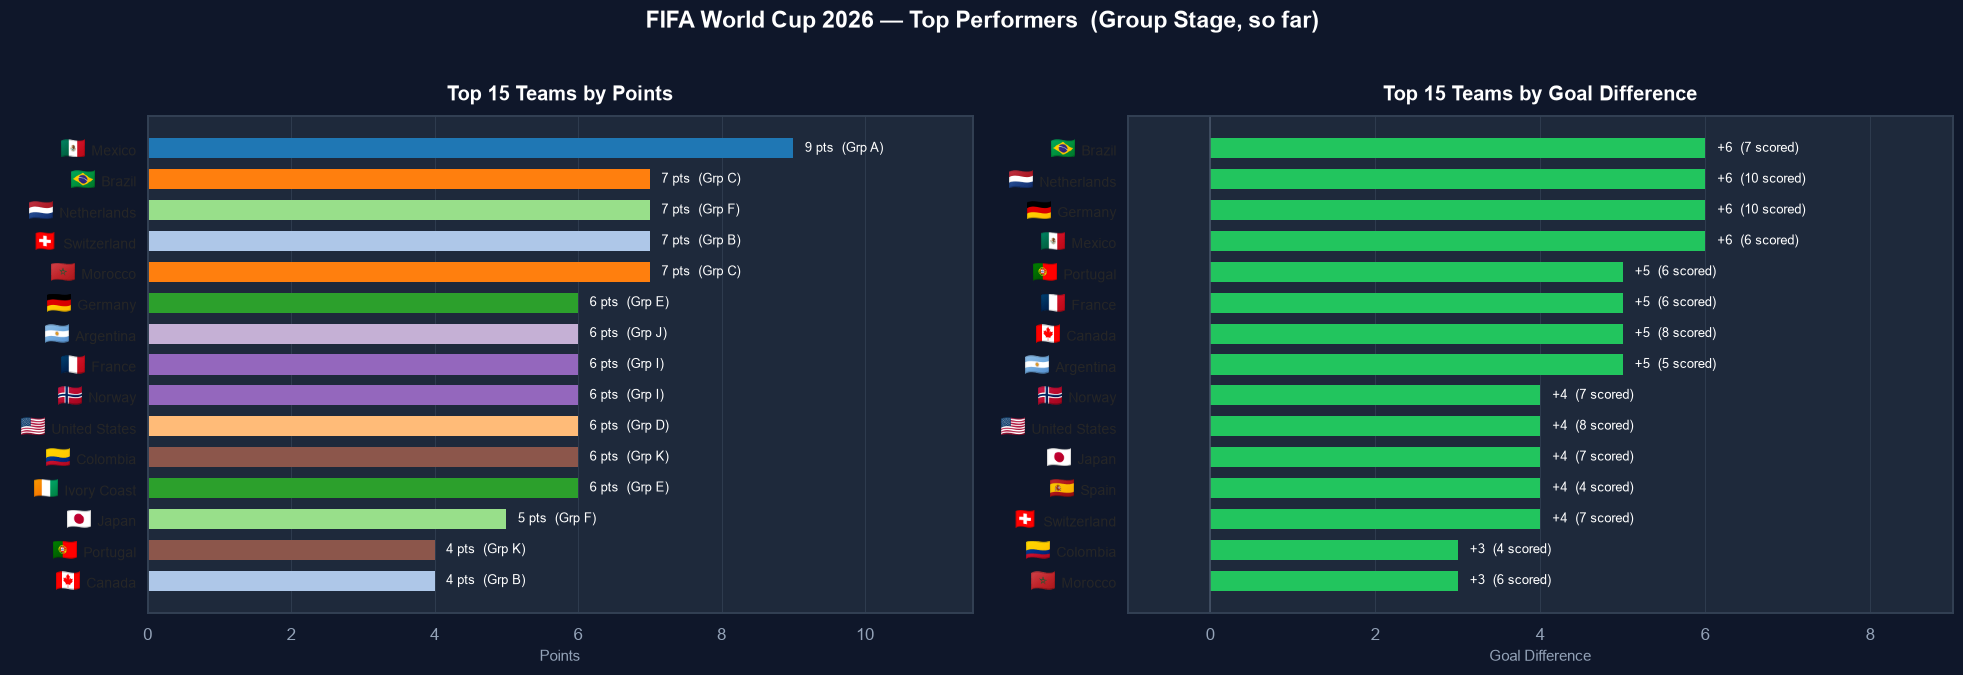

In [33]:
# ── Top teams by points & goal difference (partial standings) ─────────────────────
all_standings = []
for grp in sorted(group_matches['group'].unique()):
    s = build_standings(group_matches[group_matches['group'] == grp])
    s['group'] = grp
    all_standings.append(s)
all_s = pd.concat(all_standings, ignore_index=True)

top_pts = all_s.nlargest(15, ['pts', 'gd', 'gf']).sort_values(['pts', 'gd'], ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0F172A')

for ax in axes:
    ax.set_facecolor('#1E293B')
    for sp in ax.spines.values():
        sp.set_color('#334155')
    ax.tick_params(colors='#94A3B8')
    ax.xaxis.label.set_color('#94A3B8')
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, color='#334155', linewidth=0.5)
    ax.set_axisbelow(True)

# — Top 15 by points —
grp_colors = {g: c for g, c in zip(sorted(group_matches['group'].unique()),
               sns.color_palette('tab20', len(group_matches['group'].unique())))}
bar_colors = [grp_colors[g] for g in top_pts['group']]
teams_pts = list(top_pts['team'])

axes[0].barh(teams_pts, top_pts['pts'].values, color=bar_colors, edgecolor='none', height=0.65)
for i, (_, row) in enumerate(top_pts.iterrows()):
    axes[0].text(row['pts'] + 0.05, i, f"  {int(row['pts'])} pts  (Grp {row['group']})",
                 va='center', fontsize=8.5, color='white')
axes[0].set_title('Top 15 Teams by Points', fontsize=13, fontweight='bold', color='white', pad=10)
axes[0].set_xlabel('Points', fontsize=10)
axes[0].tick_params(axis='y', labelsize=9, labelcolor='white')
axes[0].set_xlim(0, top_pts['pts'].max() + 2.5)
add_flags_barh(axes[0], teams_pts, zoom=0.5)

# — Top 15 by goal difference —
top_gd = all_s.nlargest(15, ['gd', 'gf']).sort_values('gd', ascending=True)
gd_colors = ['#22C55E' if v >= 0 else '#EF4444' for v in top_gd['gd']]
teams_gd = list(top_gd['team'])

axes[1].barh(teams_gd, top_gd['gd'].values, color=gd_colors, edgecolor='none', height=0.65)
for i, (_, row) in enumerate(top_gd.iterrows()):
    sign = '+' if row['gd'] >= 0 else ''
    axes[1].text(row['gd'] + 0.05, i, f"  {sign}{int(row['gd'])}  ({int(row['gf'])} scored)",
                 va='center', fontsize=8.5, color='white')
axes[1].set_title('Top 15 Teams by Goal Difference', fontsize=13, fontweight='bold', color='white', pad=10)
axes[1].set_xlabel('Goal Difference', fontsize=10)
axes[1].tick_params(axis='y', labelsize=9, labelcolor='white')
axes[1].axvline(0, color='#475569', linewidth=1)
axes[1].set_xlim(-1, top_gd['gd'].max() + 3)
add_flags_barh(axes[1], teams_gd, zoom=0.5)

fig.suptitle('FIFA World Cup 2026 — Top Performers  (Group Stage, so far)',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()


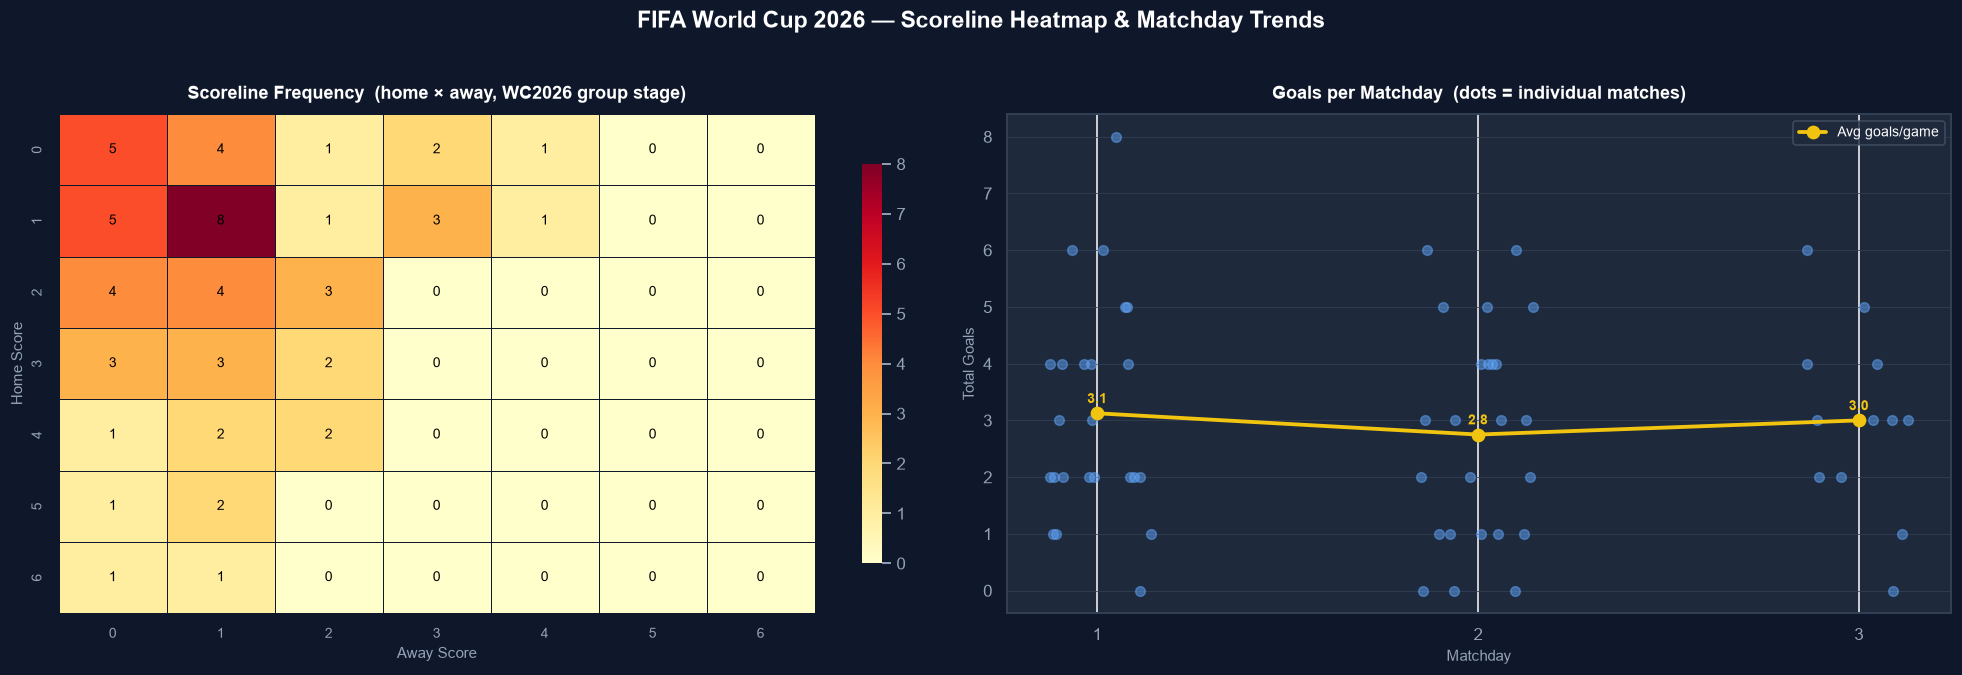

In [34]:
# ── Scoreline heatmap + goals-per-game timeline ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0F172A')

for ax in axes:
    ax.set_facecolor('#1E293B')

# — Scoreline heatmap —
cap = 6
hm = group_matches.copy()
hm['hs'] = hm['home_score'].clip(0, cap)
hm['as'] = hm['away_score'].clip(0, cap)
heat = hm.groupby(['hs', 'as']).size().unstack(fill_value=0)
heat = heat.reindex(index=range(cap+1), columns=range(cap+1), fill_value=0)

sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.4, linecolor='#0F172A',
            annot_kws={'size': 9, 'color': 'black'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Scoreline Frequency  (home × away, WC2026 group stage)',
                   fontsize=12, fontweight='bold', color='white', pad=10)
axes[0].set_xlabel('Away Score', color='#94A3B8', fontsize=10)
axes[0].set_ylabel('Home Score', color='#94A3B8', fontsize=10)
axes[0].tick_params(colors='#94A3B8', labelsize=9)
axes[0].collections[0].colorbar.ax.tick_params(colors='#94A3B8')

# — Goals per matchday scatter + avg line —
md_goals = group_matches.groupby('matchday').agg(
    goals=('total_goals', 'sum'),
    matches=('match_id', 'count'),
).reset_index()
md_goals['gpg'] = md_goals['goals'] / md_goals['matches']

# individual match dots
for _, row in group_matches.iterrows():
    axes[1].scatter(row['matchday'] + np.random.uniform(-0.15, 0.15),
                    row['total_goals'], color='#60A5FA', alpha=0.5, s=40, zorder=2)

axes[1].plot(md_goals['matchday'], md_goals['gpg'], 'o-',
             color='#F1C40F', linewidth=2.5, markersize=8, zorder=3, label='Avg goals/game')
for _, row in md_goals.iterrows():
    axes[1].text(row['matchday'], row['gpg'] + 0.18, f"{row['gpg']:.1f}",
                 ha='center', fontsize=9, color='#F1C40F', fontweight='bold')

axes[1].set_facecolor('#1E293B')
for sp in axes[1].spines.values():
    sp.set_color('#334155')
axes[1].yaxis.grid(True, color='#334155', linewidth=0.5)
axes[1].set_axisbelow(True)
axes[1].set_title('Goals per Matchday  (dots = individual matches)',
                   fontsize=12, fontweight='bold', color='white', pad=10)
axes[1].set_xlabel('Matchday', color='#94A3B8', fontsize=10)
axes[1].set_ylabel('Total Goals', color='#94A3B8', fontsize=10)
axes[1].tick_params(colors='#94A3B8')
axes[1].set_xticks(sorted(group_matches['matchday'].unique()))
axes[1].legend(fontsize=9, labelcolor='white', facecolor='#1E293B', edgecolor='#475569')

fig.suptitle('FIFA World Cup 2026 — Scoreline Heatmap & Matchday Trends',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()